#EMPLOYEE PERFORMANCE ANALYSIS


##Importing the libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

##Reading the data file

In [ ]:
df=pd.read_excel('/content/Employee_Performance.xls')

In [ ]:
pd.set_option('display.max_columns',None) #to display all columns in dataframe

In [ ]:
df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


##EDA begins...

1. lets see the shape of dataframe

In [ ]:
df.shape

(1200, 28)

2. see some of the stats of dataframe provided

In [ ]:
df.describe() #for numerical

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


In [ ]:
df.describe(include='object') # for objects(i.e. categorical features)

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E1001000,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


3. see the datatypes of different columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

4. the null values if any present in the df

In [ ]:
df.isnull().sum()

,0
EmpNumber,0
Age,0
Gender,0
EducationBackground,0
MaritalStatus,0
EmpDepartment,0
EmpJobRole,0
BusinessTravelFrequency,0
DistanceFromHome,0
EmpEducationLevel,0


5. duplicates if any present in it

In [ ]:
df.duplicated().sum()

0

6. all the column names in the dataframe

In [ ]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

##Ploting Mania has started now

###Histograms

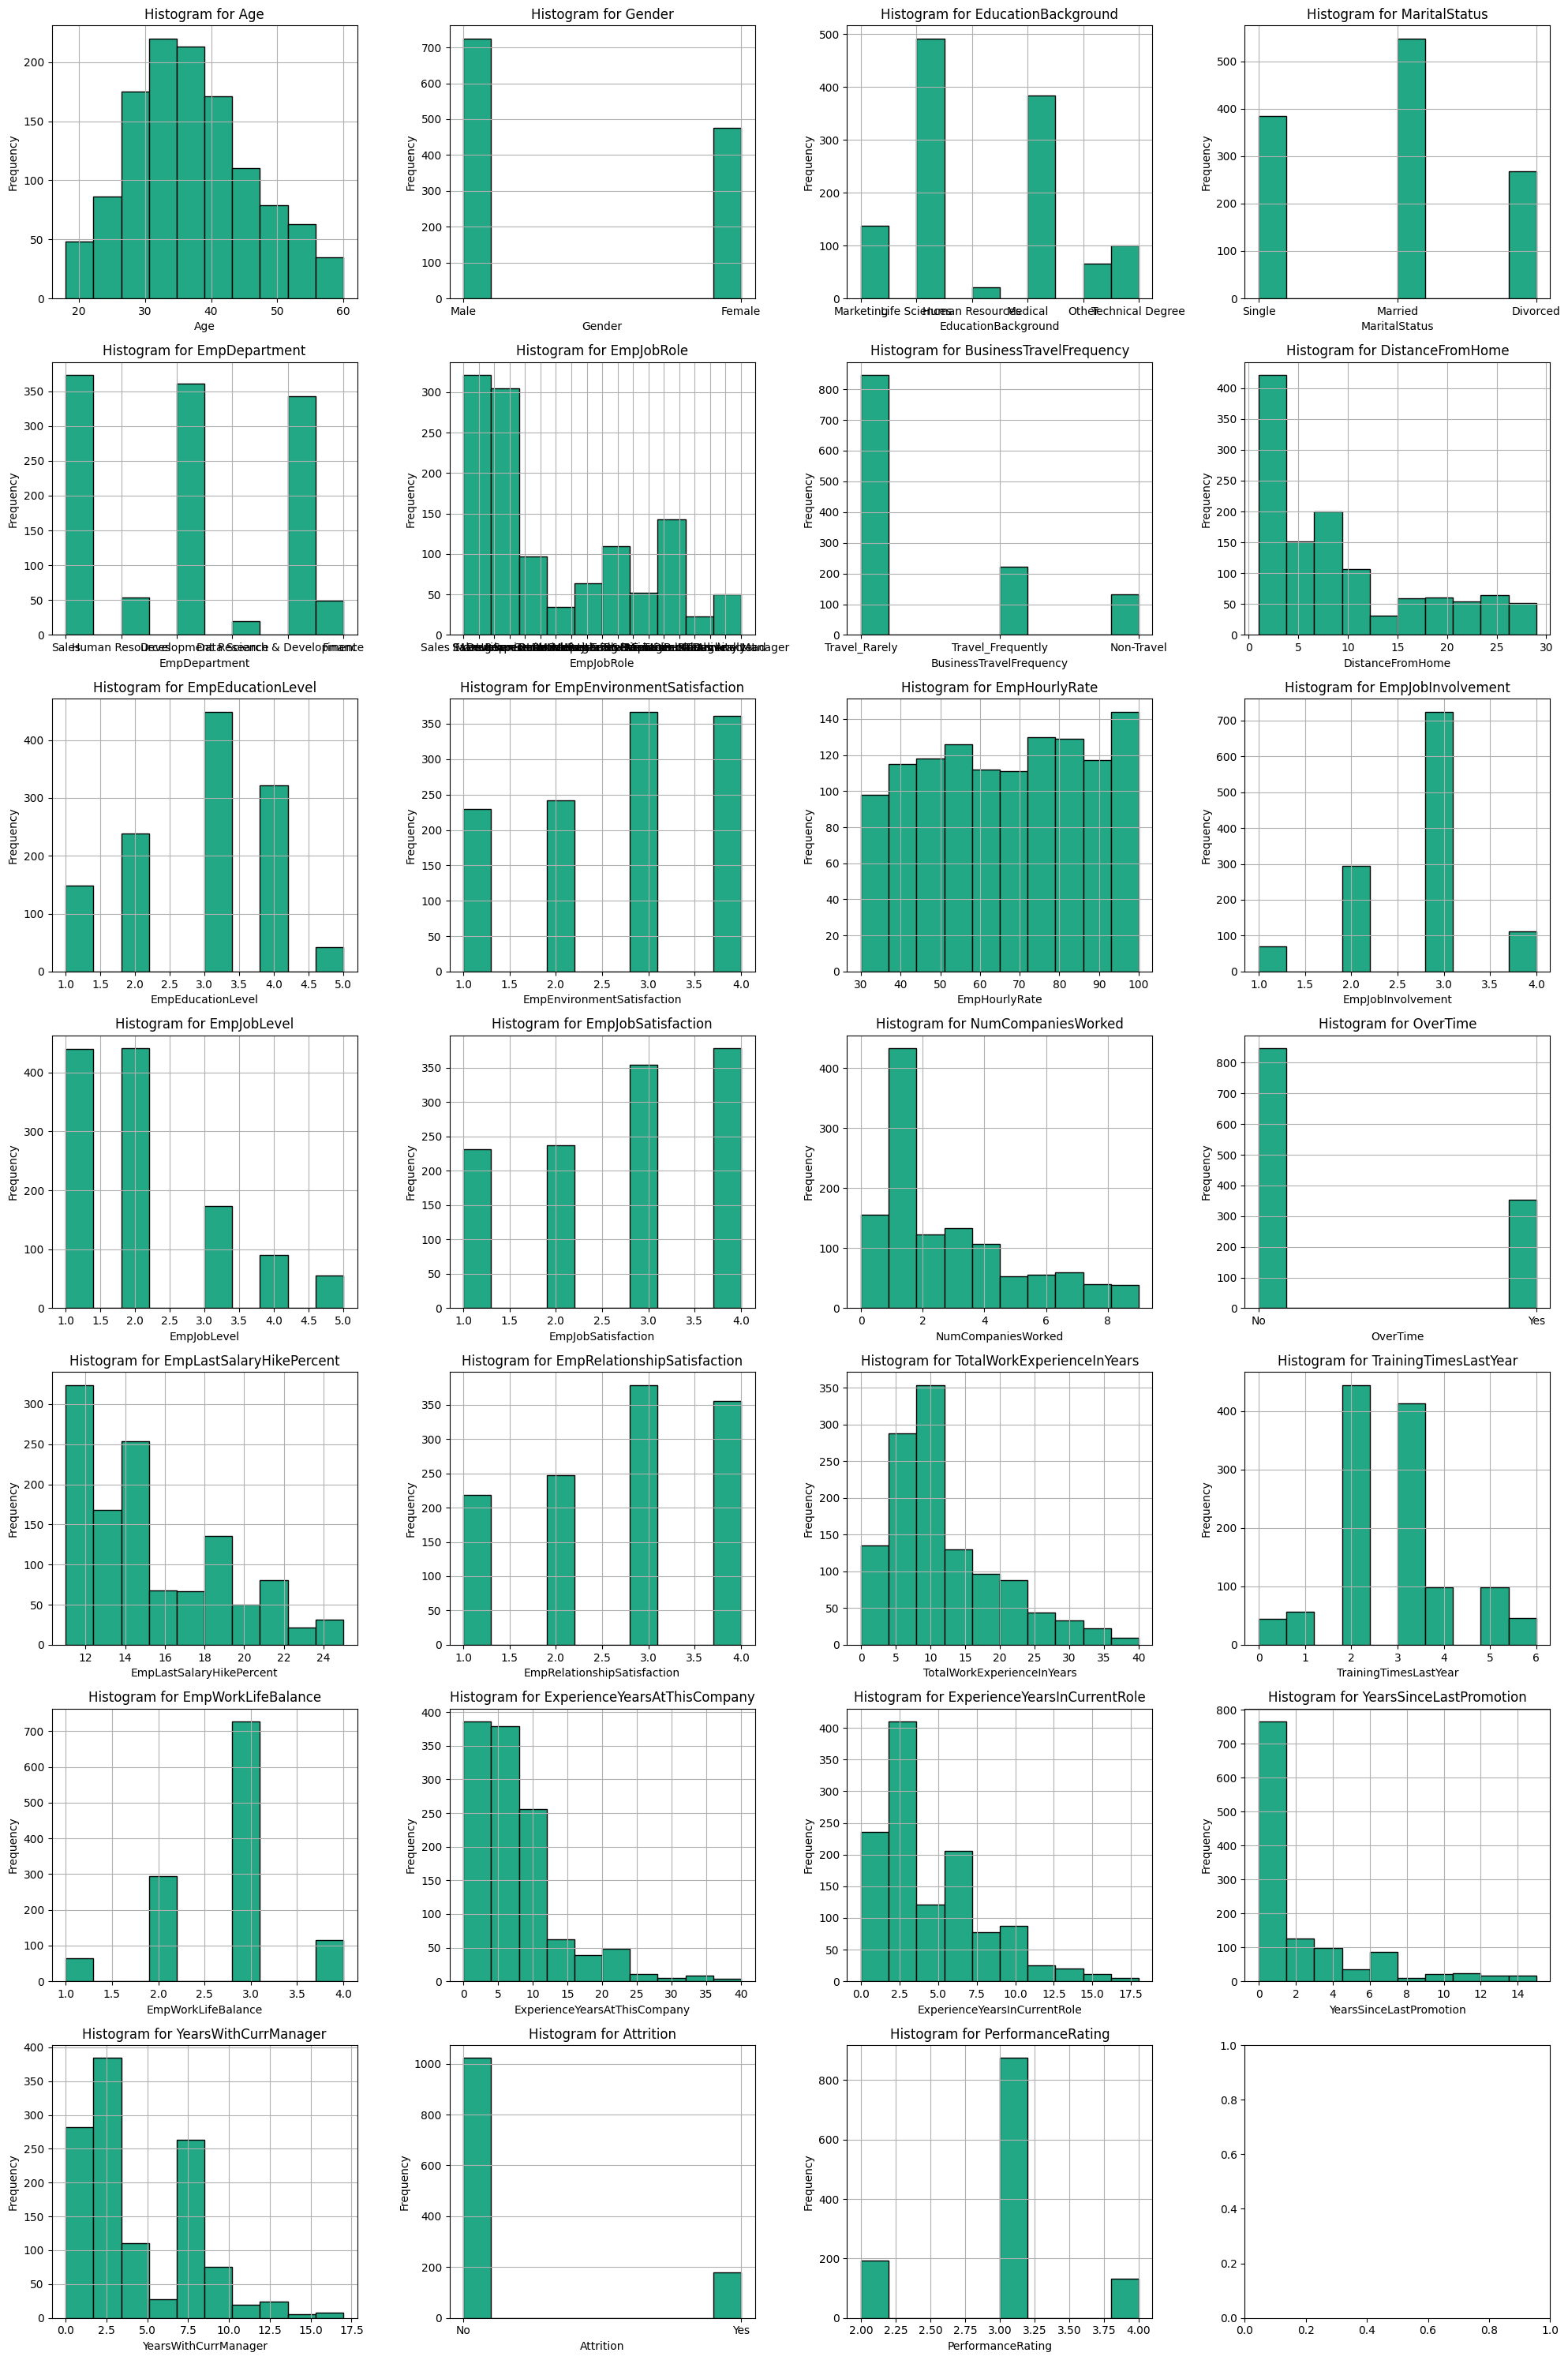

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

columns = [ 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
           'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
           'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
           'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
           'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
           'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
           'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
           'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
           'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
           'YearsWithCurrManager', 'Attrition', 'PerformanceRating']

# Setted up the subplots for a 7x4 grid (28 columns)
n_rows = 7
n_cols = 4
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 30))

# Flattened the axes array for easy iteration
axes = axes.flatten()

# Looping through each column and plot its histogram
for i, column in enumerate(columns):
    if column in df.columns:
        axes[i].hist(df[column], bins=10, edgecolor='black',color=plt.cm.viridis(0.6))
        axes[i].set_title(f'Histogram for {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True)

# Adjusted layout to avoid overlap
plt.tight_layout()

plt.show()


I see now this above would take some minutes to digest...

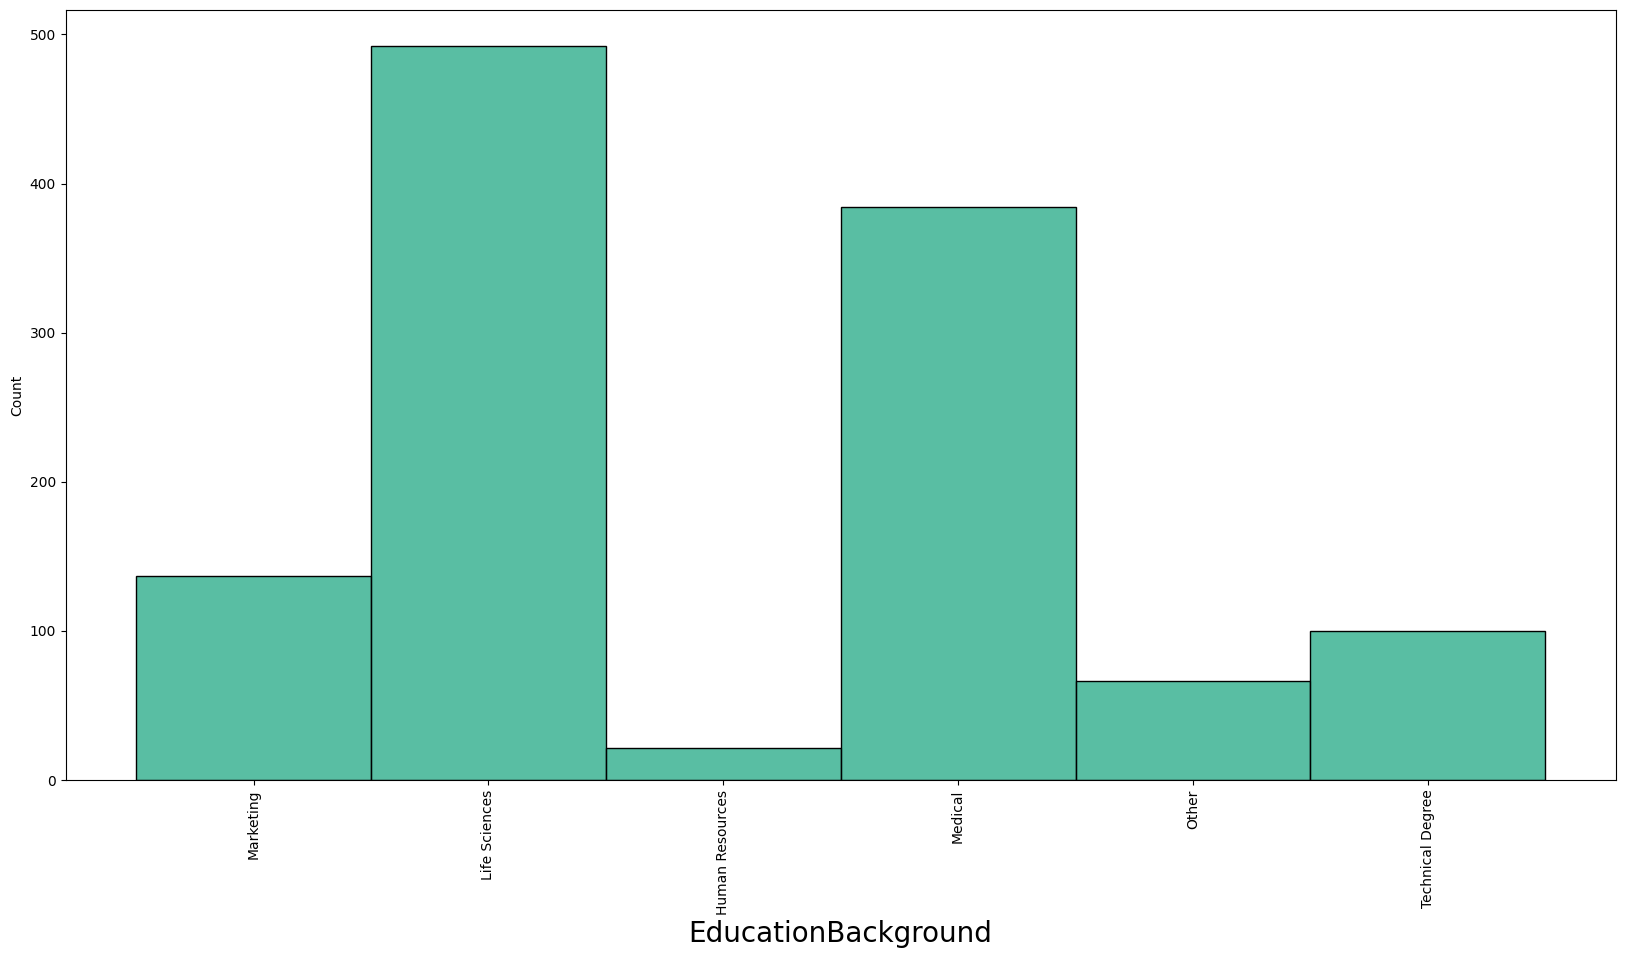

In [ ]:
plt.figure(figsize=(20,10))
sns.histplot(x='EducationBackground',data=df,color=plt.cm.viridis(0.6))
plt.xticks(rotation='vertical')
plt.xlabel('EducationBackground',fontsize=20)
plt.show()

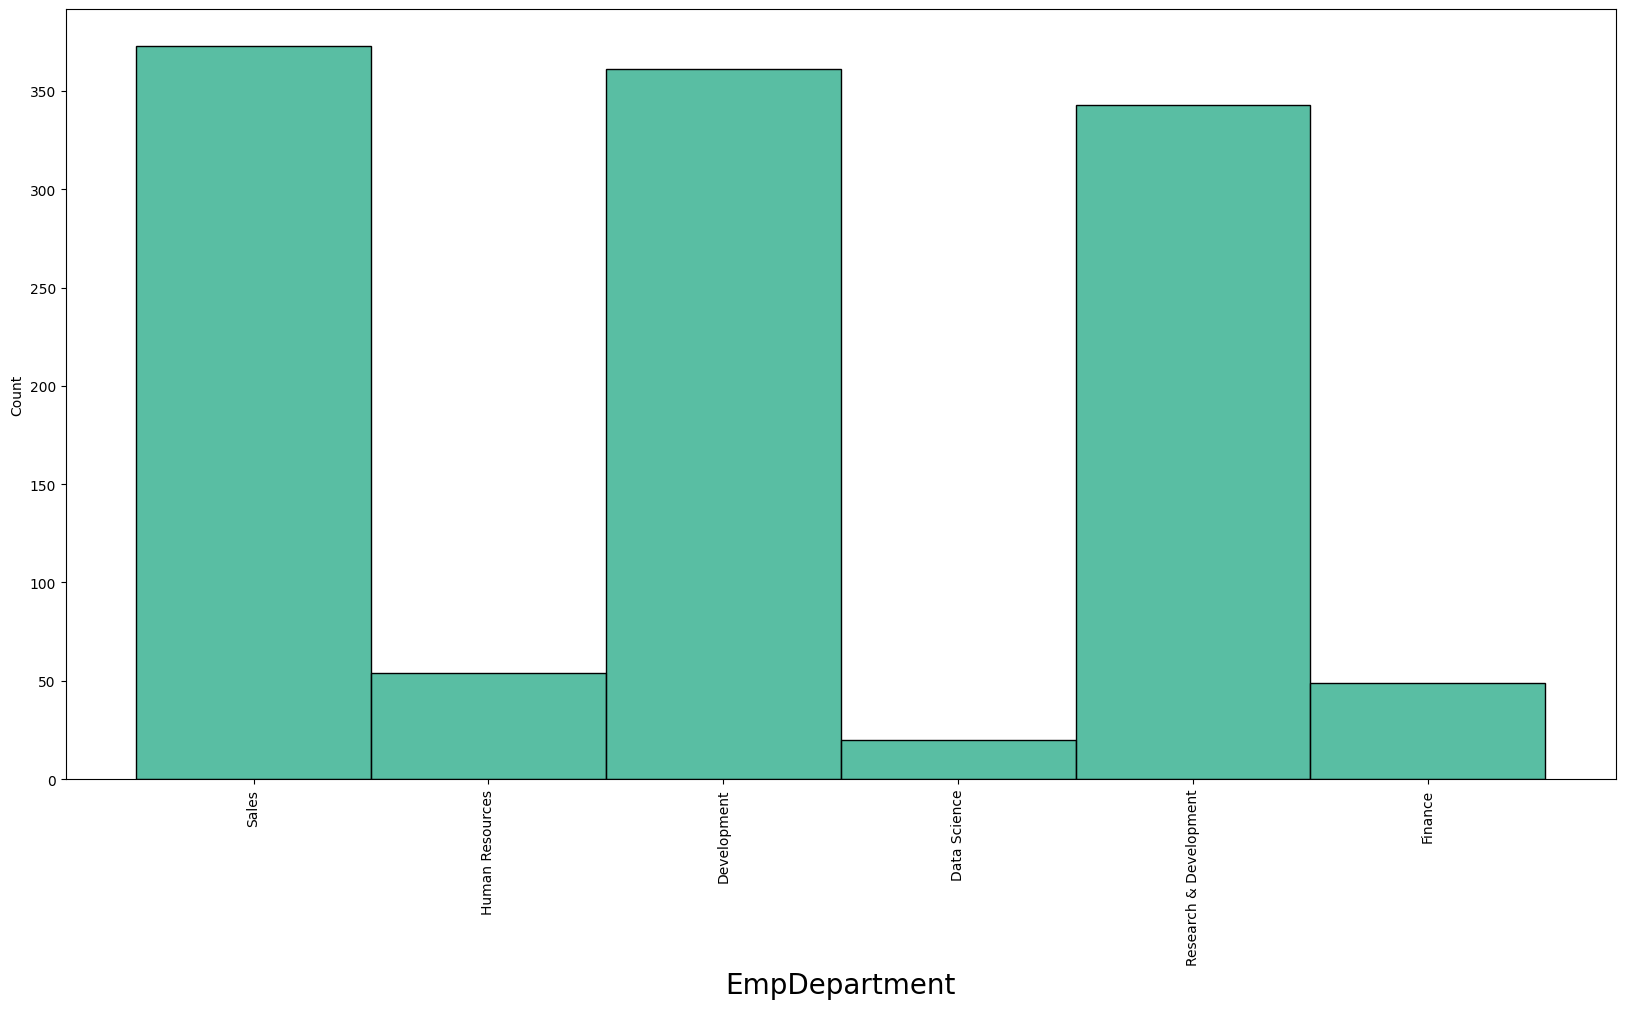

In [ ]:
plt.figure(figsize=(20,10))
sns.histplot(x='EmpDepartment',data=df,color=plt.cm.viridis(0.6))
plt.xticks(rotation='vertical')
plt.xlabel('EmpDepartment',fontsize=20)
plt.show()

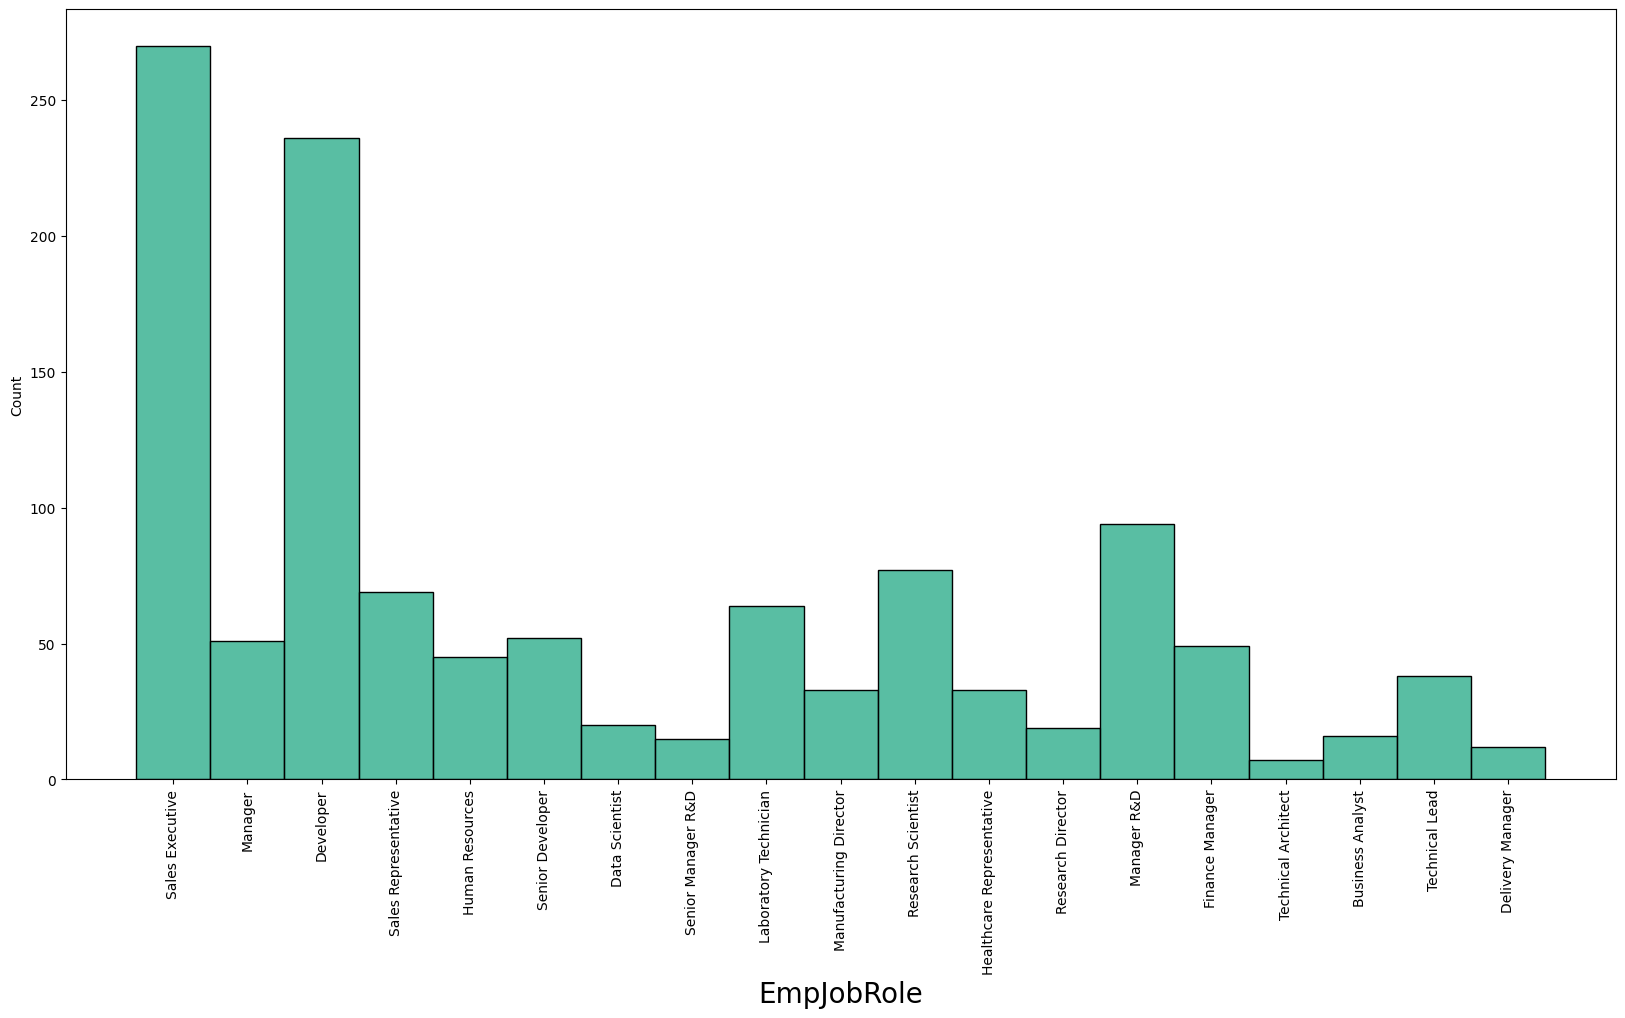

In [ ]:
plt.figure(figsize=(20,10))
sns.histplot(x='EmpJobRole',data=df,color=plt.cm.viridis(0.6))
plt.xticks(rotation='vertical')
plt.xlabel('EmpJobRole',fontsize=20)
plt.show()

###Lineplots

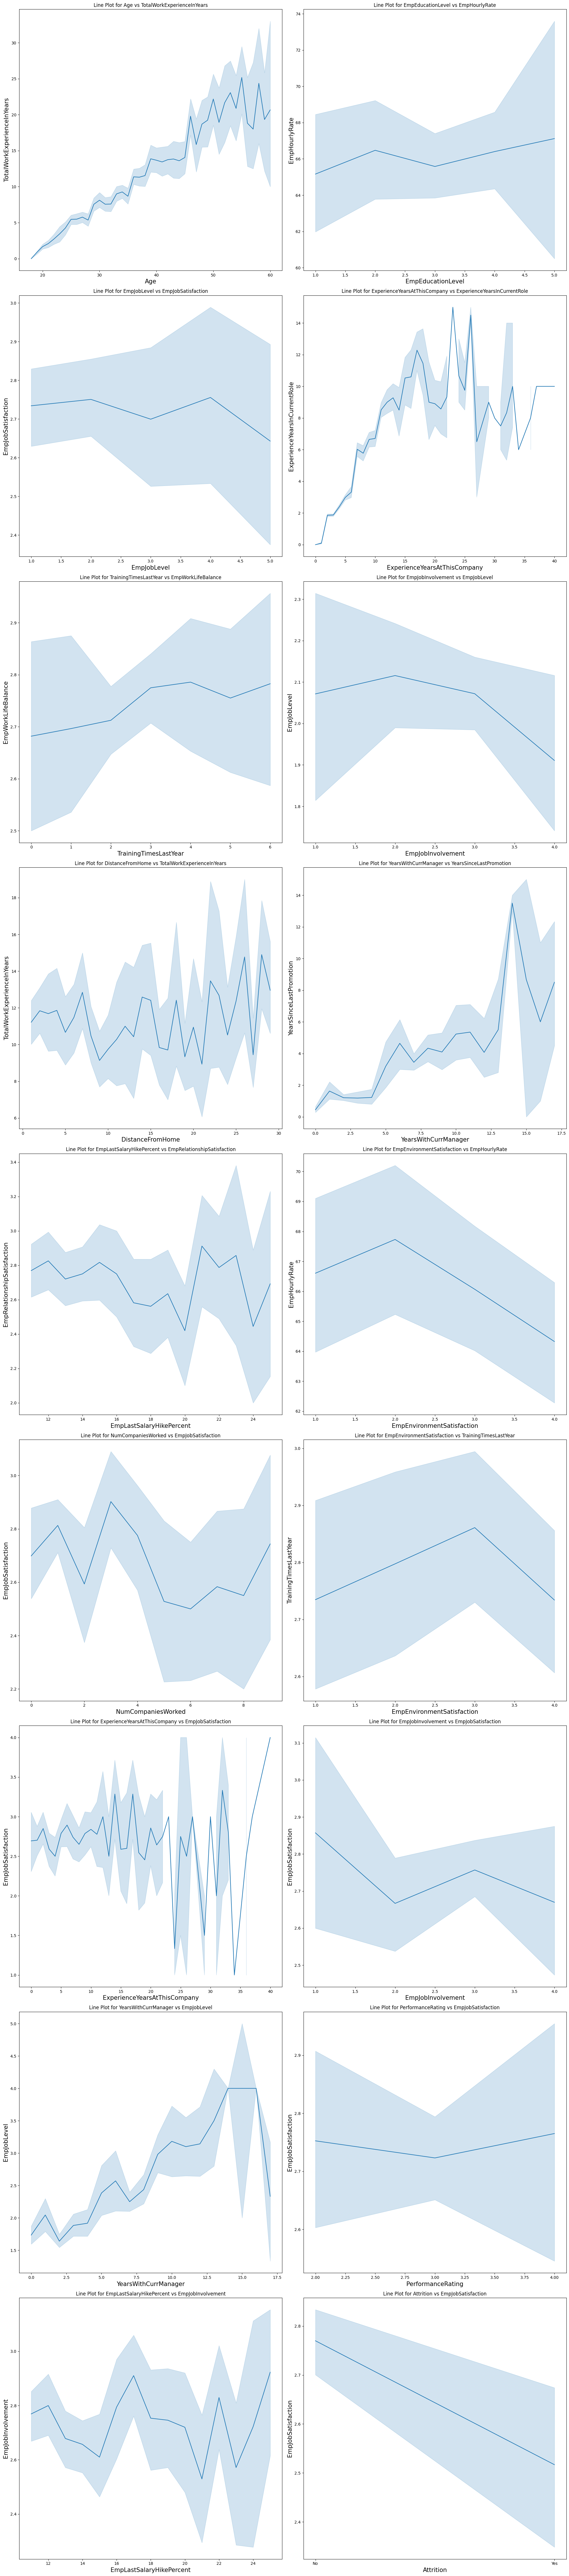

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you already have the DataFrame (df)
# List of pairs of columns you want to plot as line plots
# In this case, we'll plot pairs like 'Age' vs 'TotalWorkExperienceInYears' and others you wish
plot_pairs = [
    ('Age', 'TotalWorkExperienceInYears'),
    ('EmpEducationLevel', 'EmpHourlyRate'),
    ('EmpJobLevel', 'EmpJobSatisfaction'),
    ('ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole'),
    ('TrainingTimesLastYear', 'EmpWorkLifeBalance'),
    ('EmpJobInvolvement', 'EmpJobLevel'),
    ('DistanceFromHome', 'TotalWorkExperienceInYears'),
    ('YearsWithCurrManager', 'YearsSinceLastPromotion'),
    ('EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction'),
    ('EmpEnvironmentSatisfaction', 'EmpHourlyRate'),
    ('NumCompaniesWorked', 'EmpJobSatisfaction'),
    ('EmpEnvironmentSatisfaction', 'TrainingTimesLastYear'),
    ('ExperienceYearsAtThisCompany', 'EmpJobSatisfaction'),
    ('EmpJobInvolvement', 'EmpJobSatisfaction'),
    ('YearsWithCurrManager', 'EmpJobLevel'),
    ('PerformanceRating', 'EmpJobSatisfaction'),
    ('EmpLastSalaryHikePercent', 'EmpJobInvolvement'),
    ('Attrition', 'EmpJobSatisfaction')  # You can use numeric encoding for 'Attrition' if needed
]

# Number of rows and columns
n_rows = 9  # Number of subplots (adjust as needed)
n_cols = 2  # Number of columns in subplot grid

# Dynamically adjust the figure size based on the number of rows and columns
fig_width = 20  # Width of the figure (adjustable)
fig_height = 10 * n_rows  # Height of the figure, adjusted based on number of rows

# Set up the subplots with the calculated figsize
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(fig_width, fig_height))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Loop through the pairs of columns and plot line plots
for i, (x_col, y_col) in enumerate(plot_pairs):
    sns.lineplot(x=x_col, y=y_col, data=df, ax=axes[i])
    axes[i].set_xlabel(x_col, fontsize=15)
    axes[i].set_ylabel(y_col, fontsize=15)
    axes[i].set_title(f'Line Plot for {x_col} vs {y_col}')

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


###Categorical data came for rescue

In [ ]:
categorical = []
for c in df.columns:
    if df[c].dtype == object:
        categorical.append(c)

In [ ]:
categorical

['EmpNumber',
 'Gender',
 'EducationBackground',
 'MaritalStatus',
 'EmpDepartment',
 'EmpJobRole',
 'BusinessTravelFrequency',
 'OverTime',
 'Attrition']

In [ ]:
for c in categorical:
    print(f"{c} : {df[c].unique()}")
    print("\n")

EmpNumber : ['E1001000' 'E1001006' 'E1001007' ... 'E100994' 'E100995' 'E100998']


Gender : ['Male' 'Female']


EducationBackground : ['Marketing' 'Life Sciences' 'Human Resources' 'Medical' 'Other'
 'Technical Degree']


MaritalStatus : ['Single' 'Married' 'Divorced']


EmpDepartment : ['Sales' 'Human Resources' 'Development' 'Data Science'
 'Research & Development' 'Finance']


EmpJobRole : ['Sales Executive' 'Manager' 'Developer' 'Sales Representative'
 'Human Resources' 'Senior Developer' 'Data Scientist'
 'Senior Manager R&D' 'Laboratory Technician' 'Manufacturing Director'
 'Research Scientist' 'Healthcare Representative' 'Research Director'
 'Manager R&D' 'Finance Manager' 'Technical Architect' 'Business Analyst'
 'Technical Lead' 'Delivery Manager']


BusinessTravelFrequency : ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']


OverTime : ['No' 'Yes']


Attrition : ['No' 'Yes']




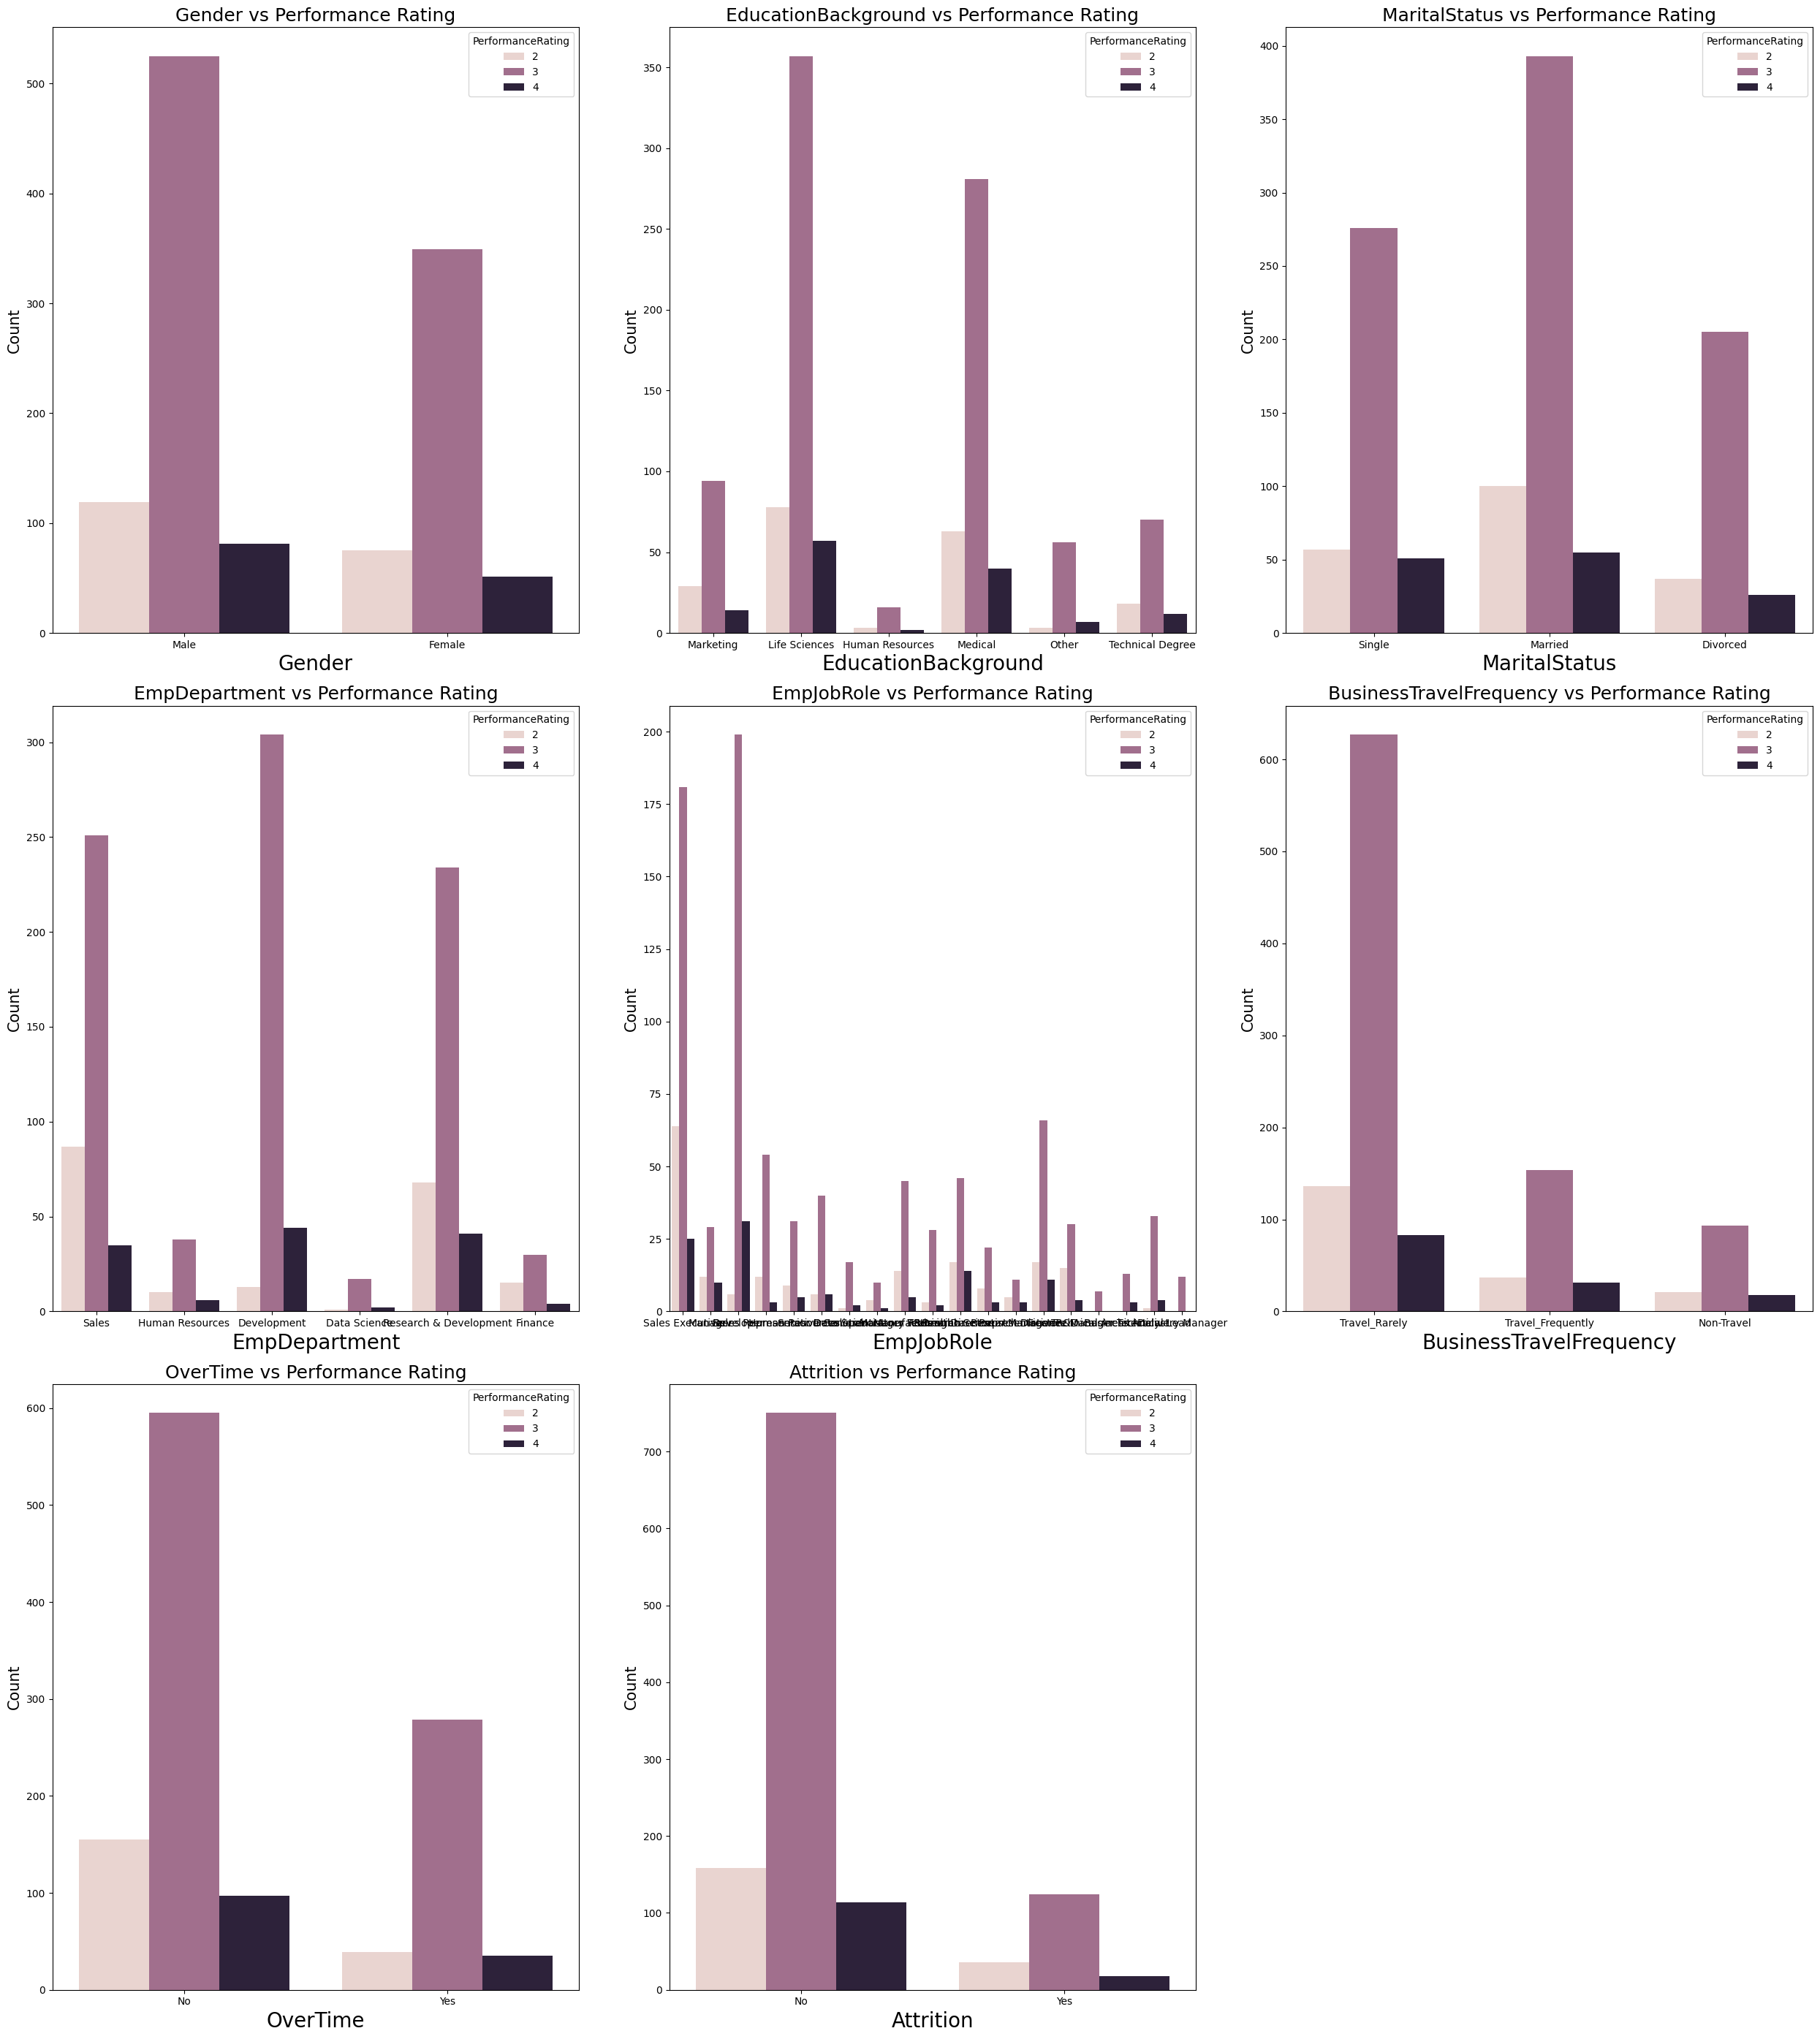

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_col = df[['Gender',
                      'EducationBackground',
                      'MaritalStatus',
                      'EmpDepartment',
                      'EmpJobRole',
                      'BusinessTravelFrequency',
                      'OverTime',
                      'Attrition']]

# Sets the figure size
plt.figure(figsize=(25, 28))

# Looping through each categorical column
i = 1
for column in categorical_col:
    plt.subplot(3, 3, i)
    sns.countplot(x=column, hue='PerformanceRating', data=df)
    plt.xlabel(column, fontsize=20)
    plt.ylabel('Count', fontsize=15)
    plt.title(f'{column} vs Performance Rating', fontsize=18)
    i += 1

plt.tight_layout()

plt.show()


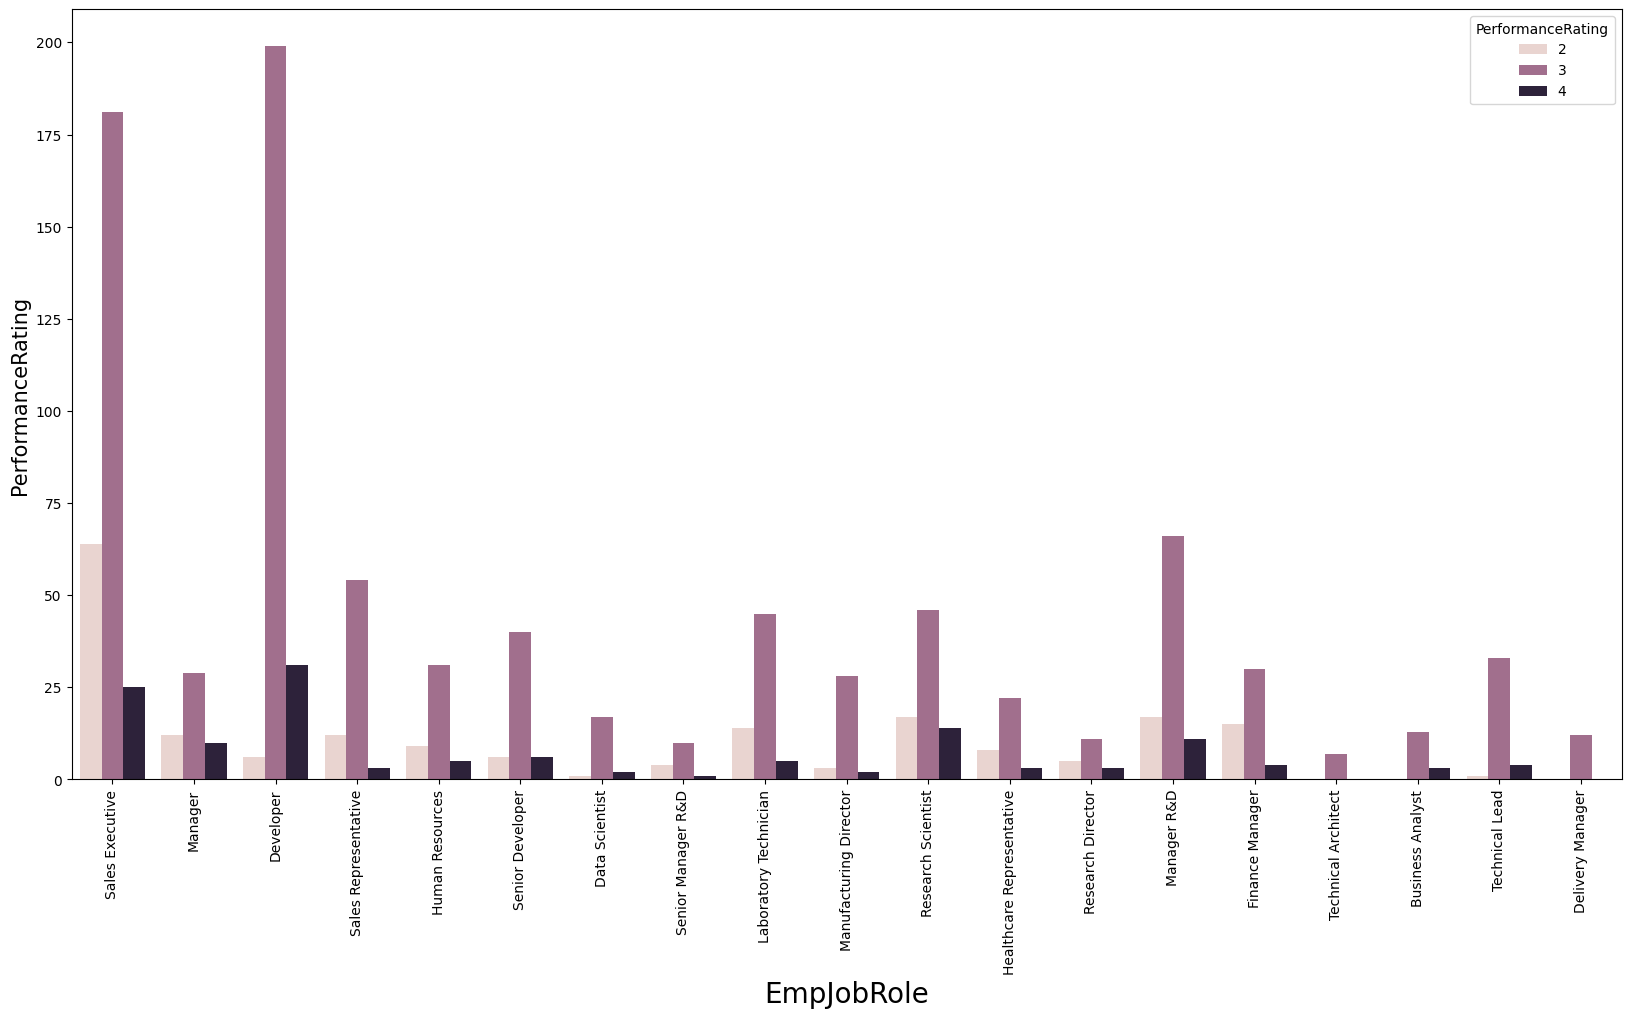

In [ ]:
plt.figure(figsize=(20,10))
sns.countplot(x='EmpJobRole',hue=df.PerformanceRating,data=df)
plt.xticks(rotation='vertical')
plt.xlabel('EmpJobRole',fontsize=20)
plt.ylabel('PerformanceRating',fontsize=15)
plt.show()


###dig deep into numerical data

In [ ]:
numerical_col = []
for column in df.columns:
    if df[column].dtype == "int64":
        df[column].unique()
        numerical_col.append(column)

In [ ]:
numeric_columns

['Age',
 'DistanceFromHome',
 'EmpEducationLevel',
 'EmpEnvironmentSatisfaction',
 'EmpHourlyRate',
 'EmpJobInvolvement',
 'EmpJobLevel',
 'EmpJobSatisfaction',
 'NumCompaniesWorked',
 'EmpLastSalaryHikePercent',
 'EmpRelationshipSatisfaction',
 'TotalWorkExperienceInYears',
 'TrainingTimesLastYear',
 'EmpWorkLifeBalance',
 'ExperienceYearsAtThisCompany',
 'ExperienceYearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'PerformanceRating']

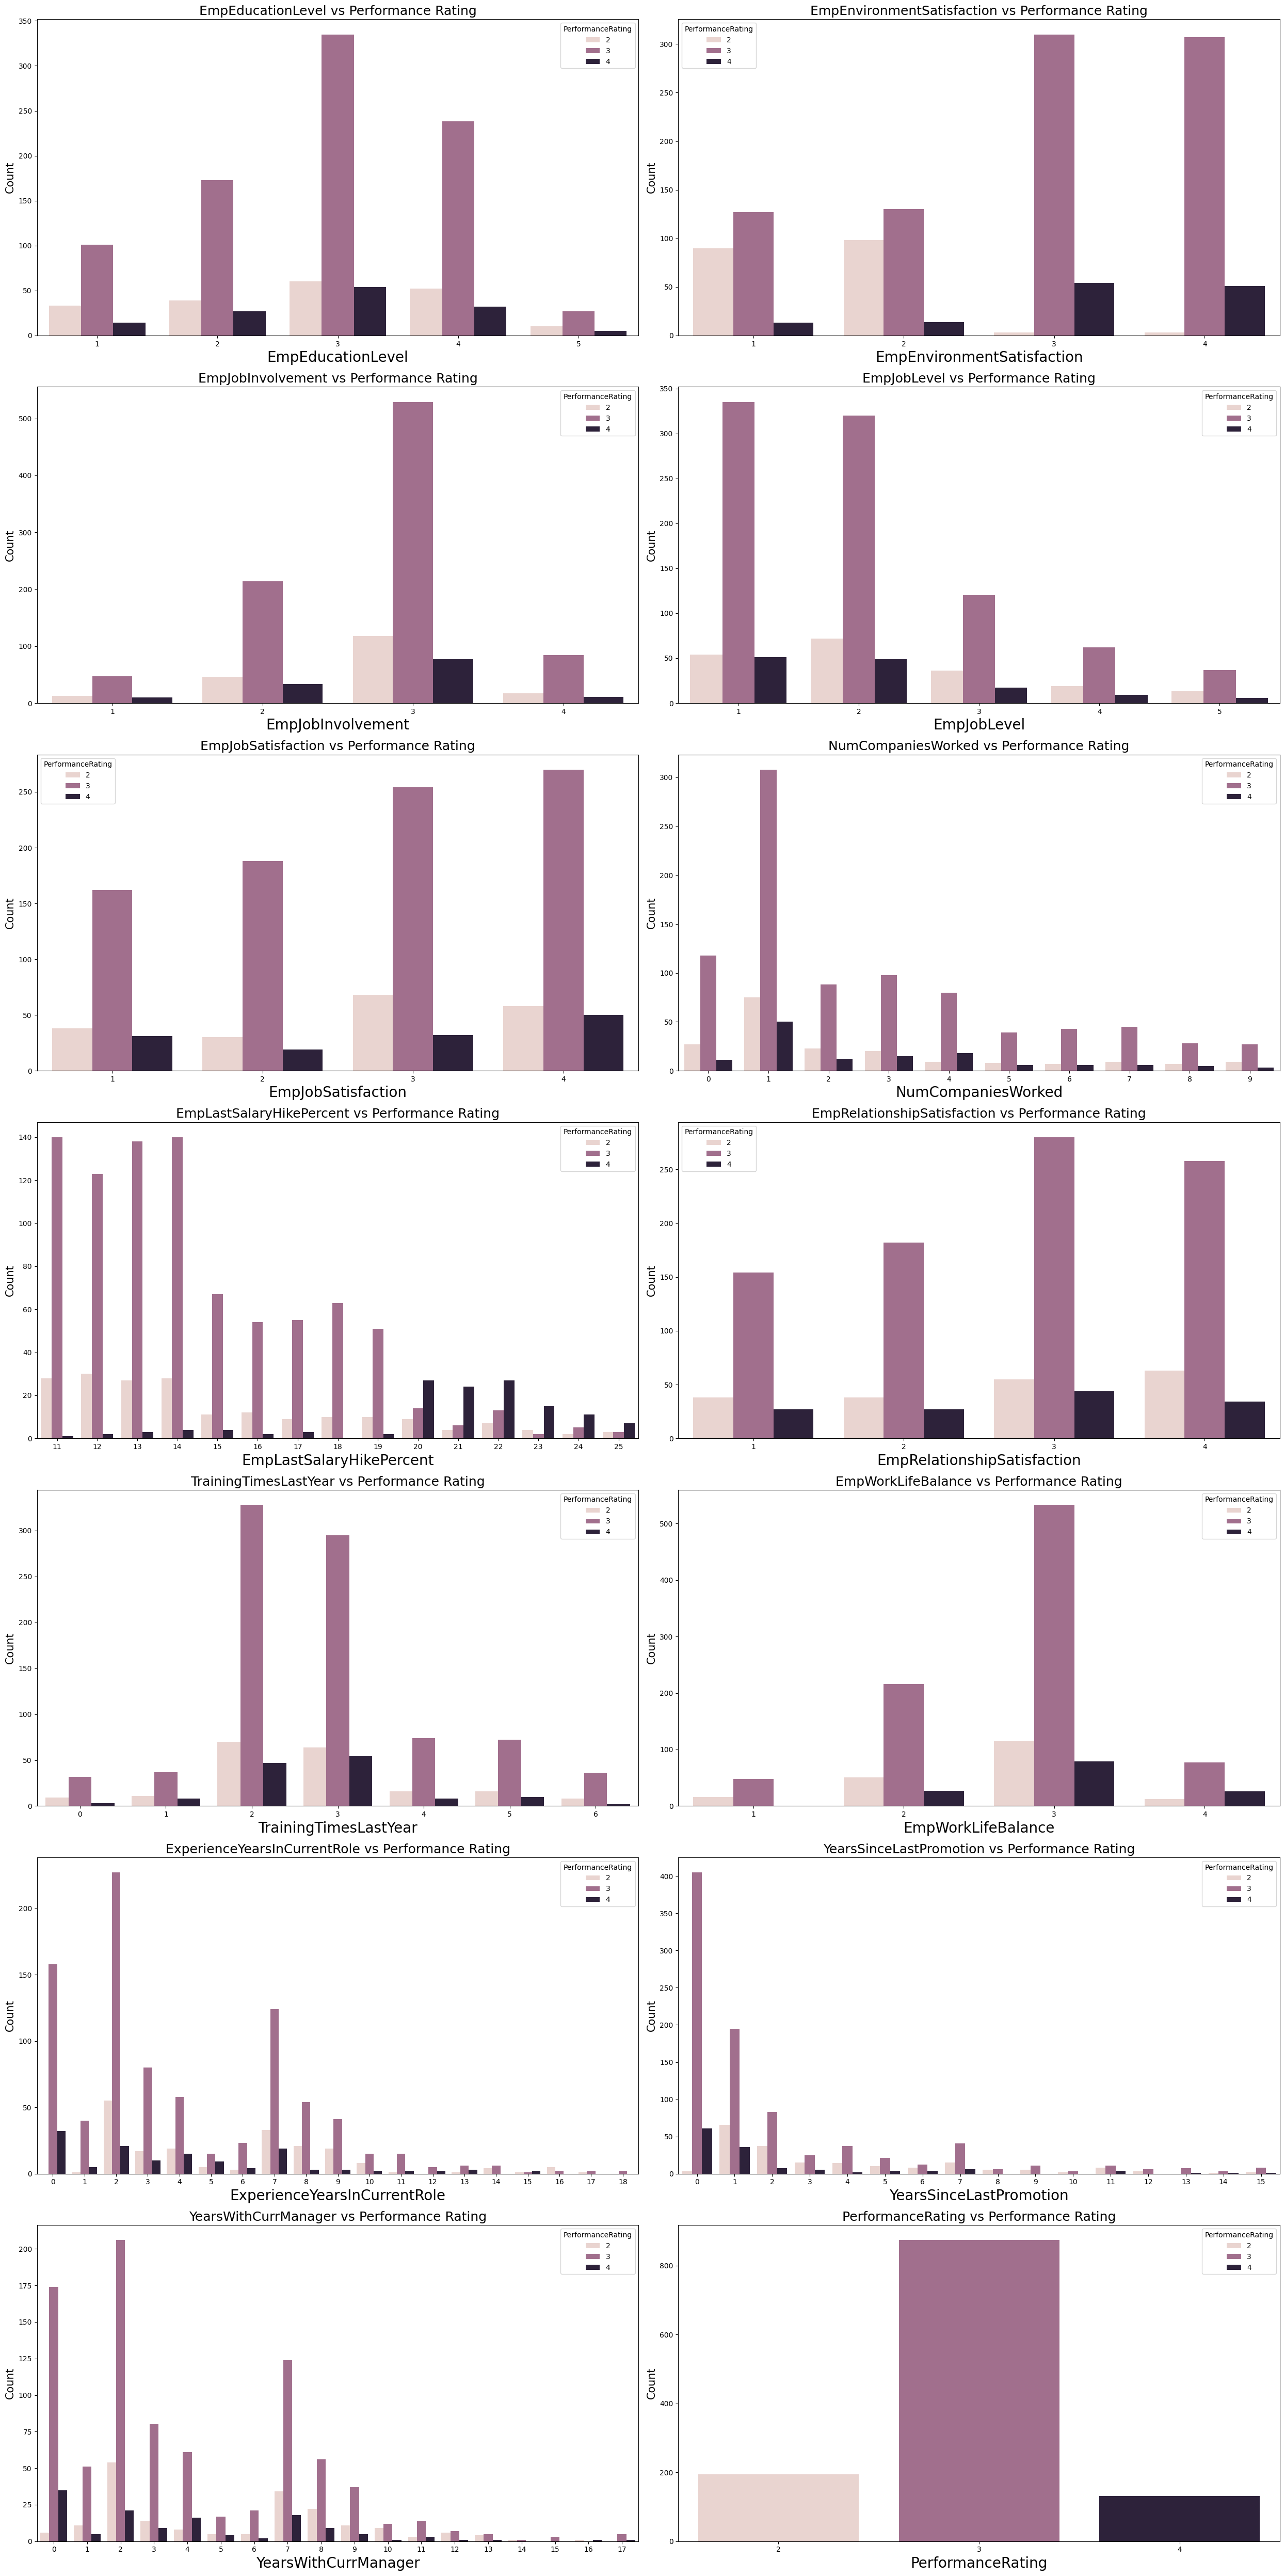

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_col = df[['EmpEducationLevel',
                    'EmpEnvironmentSatisfaction',
                    'EmpJobInvolvement',
                    'EmpJobLevel',
                    'EmpJobSatisfaction',
                    'NumCompaniesWorked',
                    'EmpLastSalaryHikePercent',
                    'EmpRelationshipSatisfaction',
                    'TrainingTimesLastYear',
                    'EmpWorkLifeBalance',
                    'ExperienceYearsInCurrentRole',
                    'YearsSinceLastPromotion',
                    'YearsWithCurrManager',
                    'PerformanceRating']]

# Sets the figure size
plt.figure(figsize=(25,50))

# Looping through each categorical column
i = 1
for column in categorical_col:
    plt.subplot(7, 2, i)
    sns.countplot(x=column, hue='PerformanceRating', data=df)
    plt.xlabel(column, fontsize=20)
    plt.ylabel('Count', fontsize=15)
    plt.title(f'{column} vs Performance Rating', fontsize=18)
    i += 1

plt.tight_layout()

plt.show()


###fast pace random plots incomming

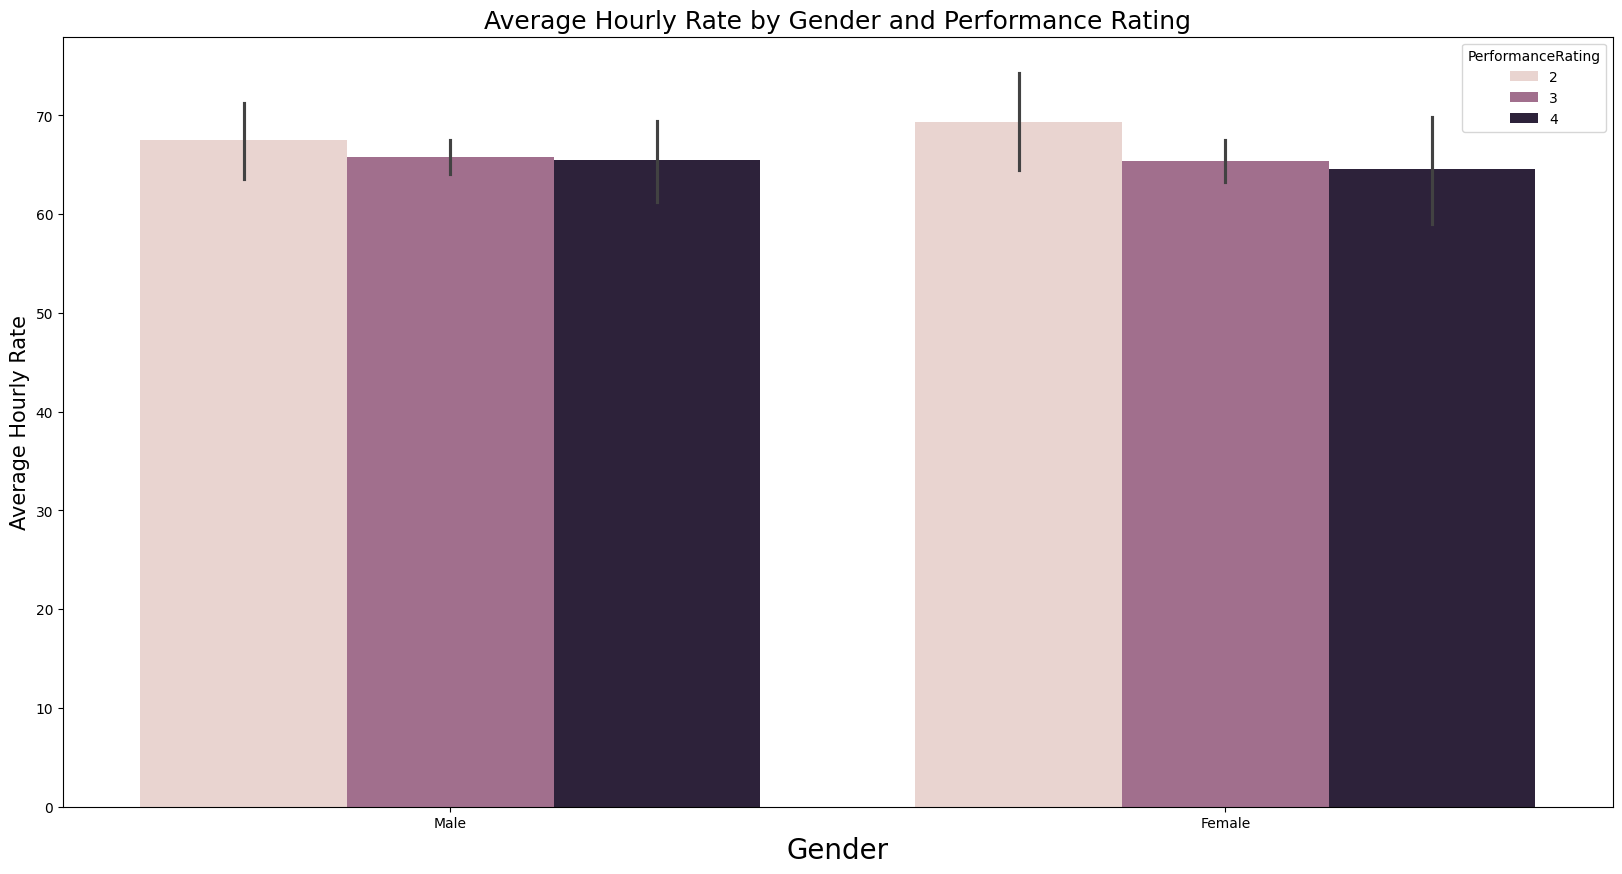

In [ ]:
plt.figure(figsize=(20, 10))
sns.barplot(x='Gender', y='EmpHourlyRate', hue='PerformanceRating', data=df)
plt.xlabel('Gender', fontsize=20)
plt.ylabel('Average Hourly Rate', fontsize=15)
plt.title('Average Hourly Rate by Gender and Performance Rating', fontsize=18)
plt.show()


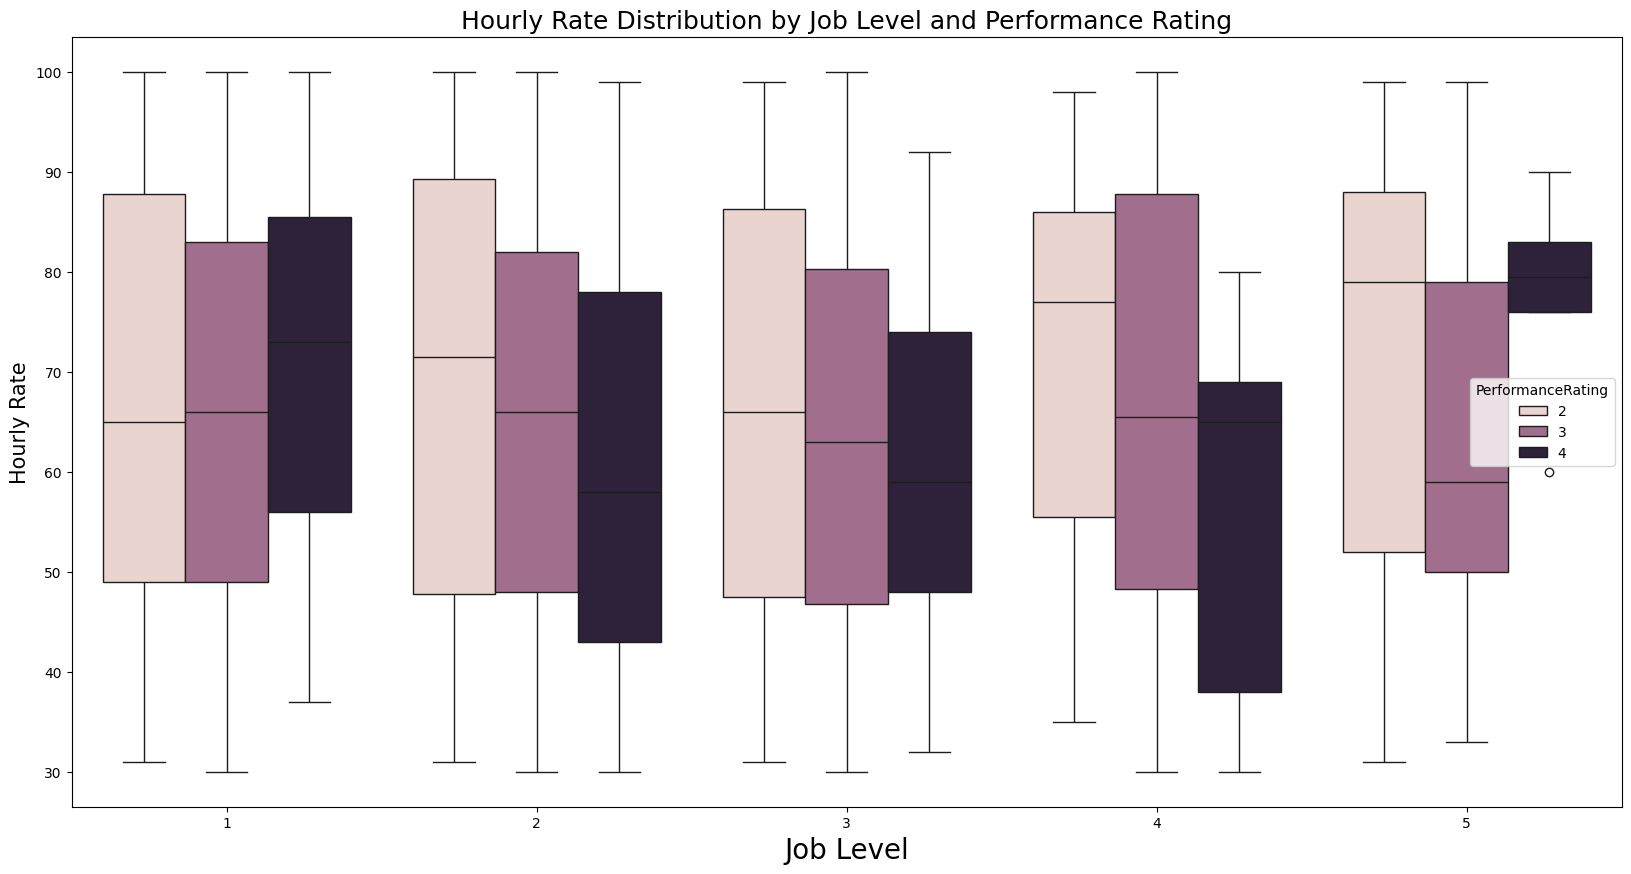

In [ ]:
plt.figure(figsize=(20, 10))
sns.boxplot(x='EmpJobLevel', y='EmpHourlyRate', hue='PerformanceRating', data=df)
plt.xlabel('Job Level', fontsize=20)
plt.ylabel('Hourly Rate', fontsize=15)
plt.title('Hourly Rate Distribution by Job Level and Performance Rating', fontsize=18)
plt.show()


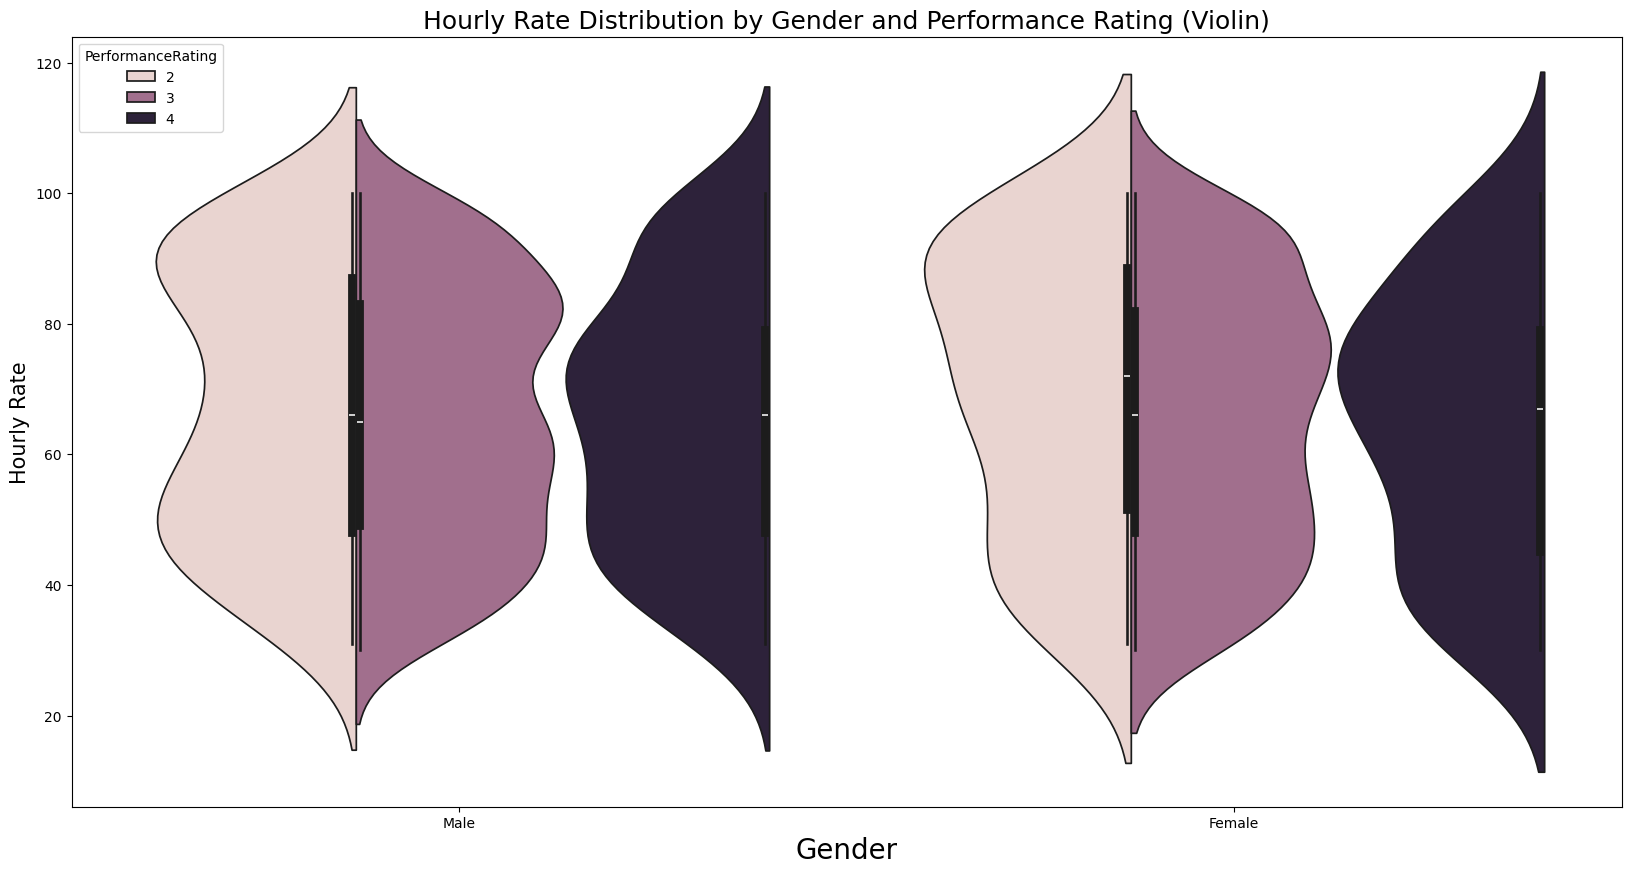

In [ ]:
plt.figure(figsize=(20, 10))
sns.violinplot(x='Gender', y='EmpHourlyRate', hue='PerformanceRating', data=data, split=True)
plt.xlabel('Gender', fontsize=20)
plt.ylabel('Hourly Rate', fontsize=15)
plt.title('Hourly Rate Distribution by Gender and Performance Rating (Violin)', fontsize=18)
plt.show()


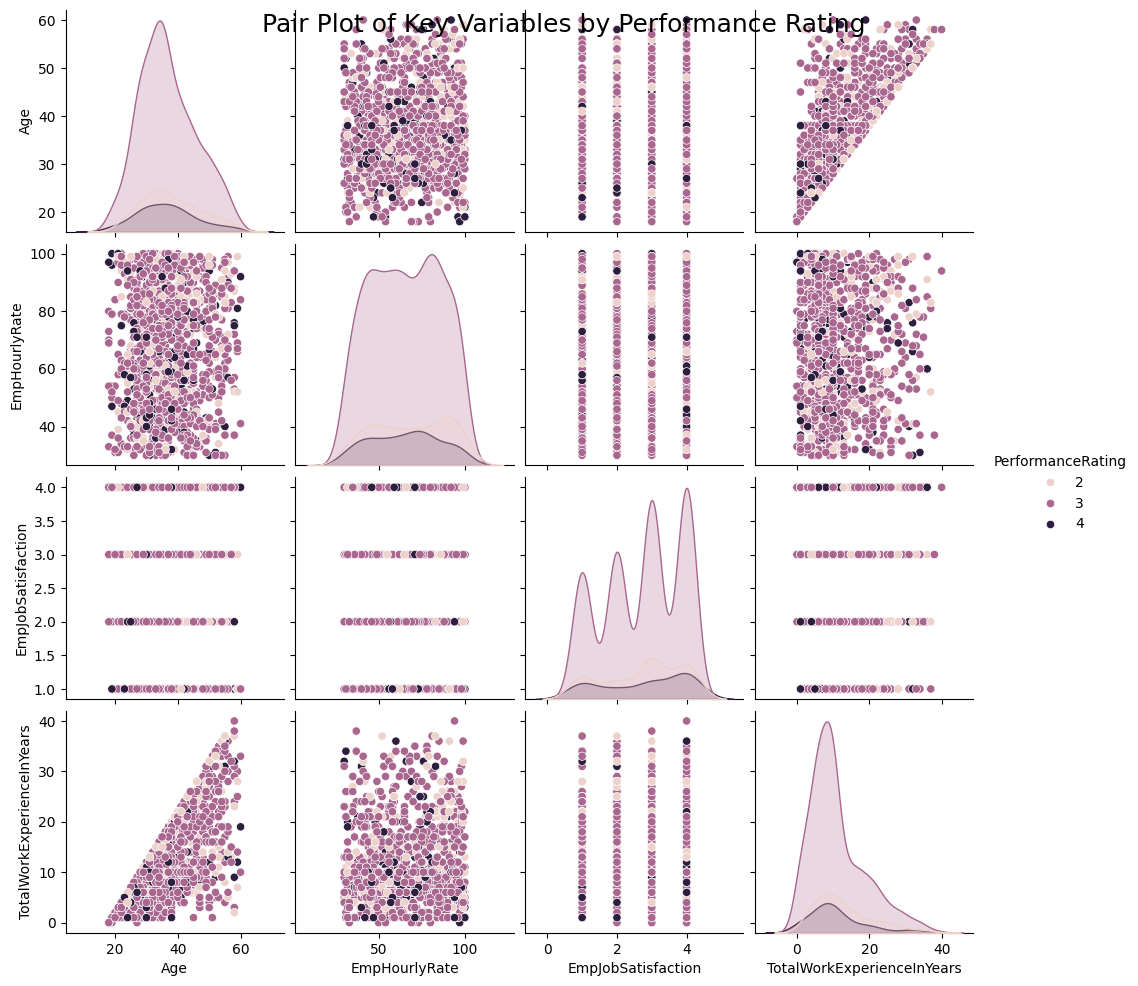

In [ ]:
sns.pairplot(data, vars=['Age', 'EmpHourlyRate', 'EmpJobSatisfaction', 'TotalWorkExperienceInYears'], hue='PerformanceRating')
plt.suptitle('Pair Plot of Key Variables by Performance Rating', fontsize=18)
plt.show()


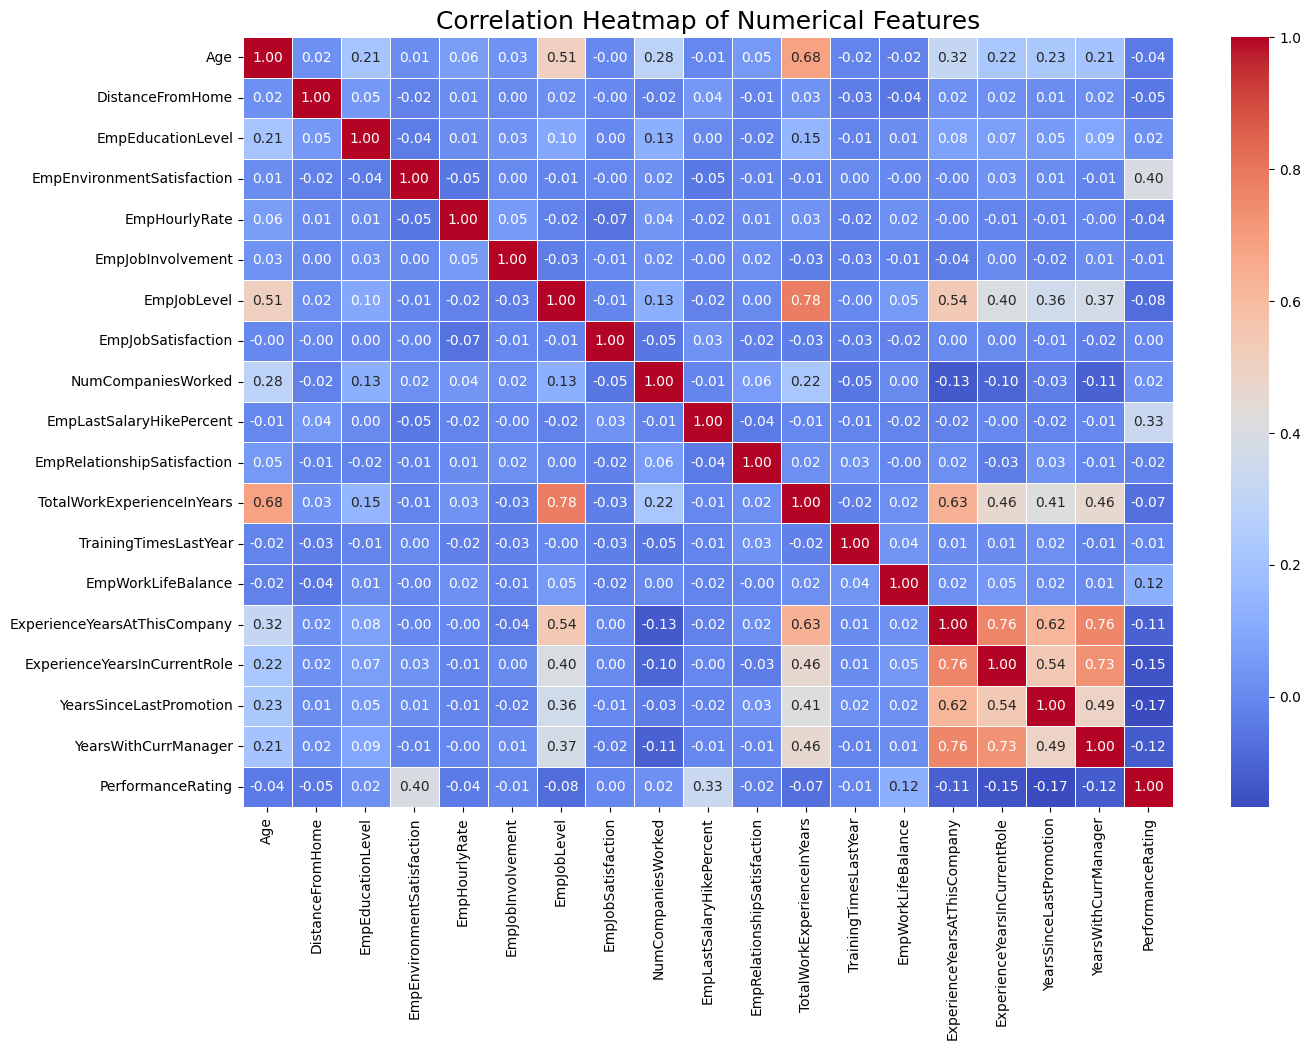

In [ ]:
plt.figure(figsize=(15, 10))
correlation_matrix = df[numeric_columns].corr()  # Compute correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=18)
plt.show()


###FacetGrid for better cmoparative understanding

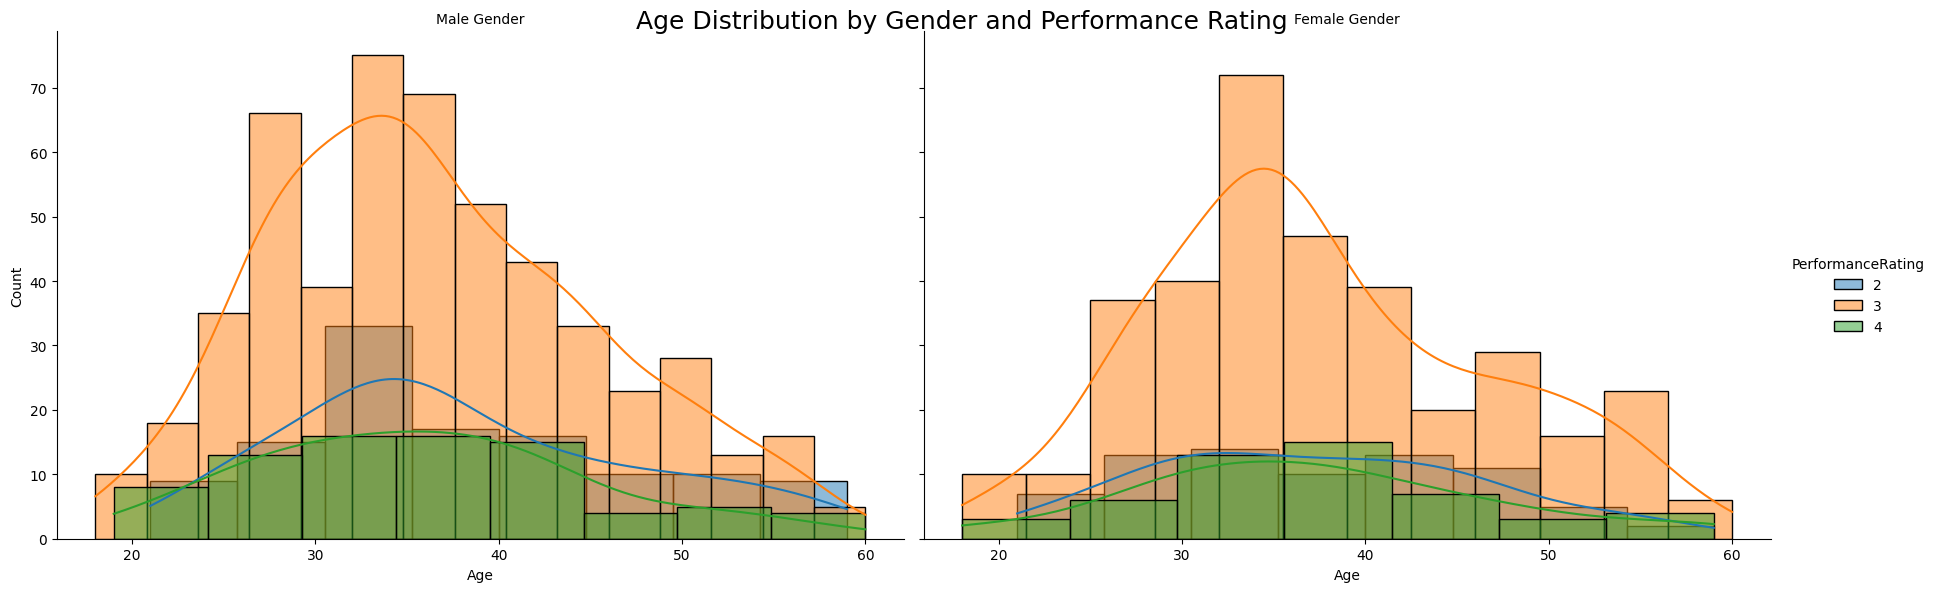

In [ ]:
g = sns.FacetGrid(df, col="Gender", hue="PerformanceRating", height=6, aspect=1.5)
g.map(sns.histplot, 'Age', kde=True)
g.add_legend()
g.set_axis_labels('Age', 'Count')
g.set_titles("{col_name} Gender")
plt.suptitle('Age Distribution by Gender and Performance Rating', fontsize=18)
plt.show()


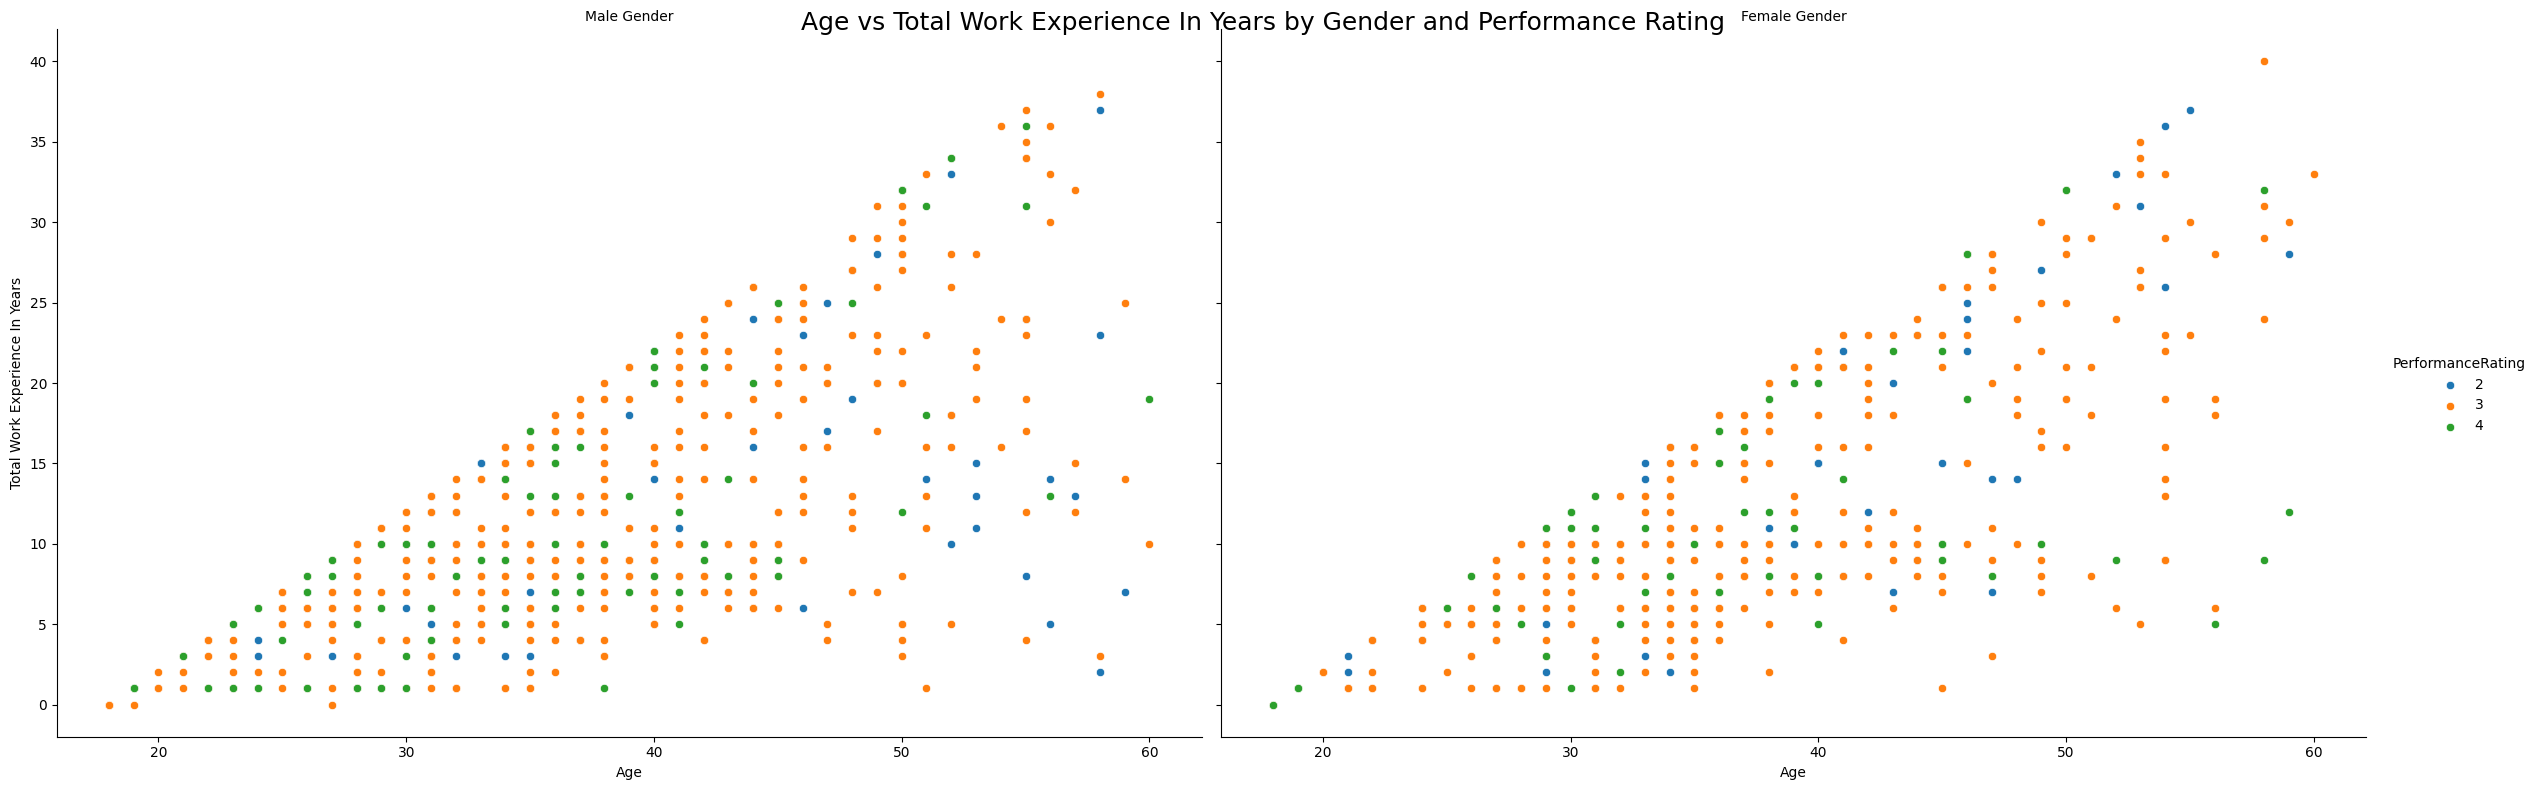

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# FacetGrid for scatter plots, conditioned on Gender
g = sns.FacetGrid(df, col="Gender", hue="PerformanceRating", height=8, aspect=1.5)
g.map(sns.scatterplot, 'Age', 'TotalWorkExperienceInYears')
g.add_legend()
g.set_axis_labels('Age', 'Total Work Experience In Years')
g.set_titles("{col_name} Gender")
plt.suptitle('Age vs Total Work Experience In Years by Gender and Performance Rating', fontsize=18)
plt.show()


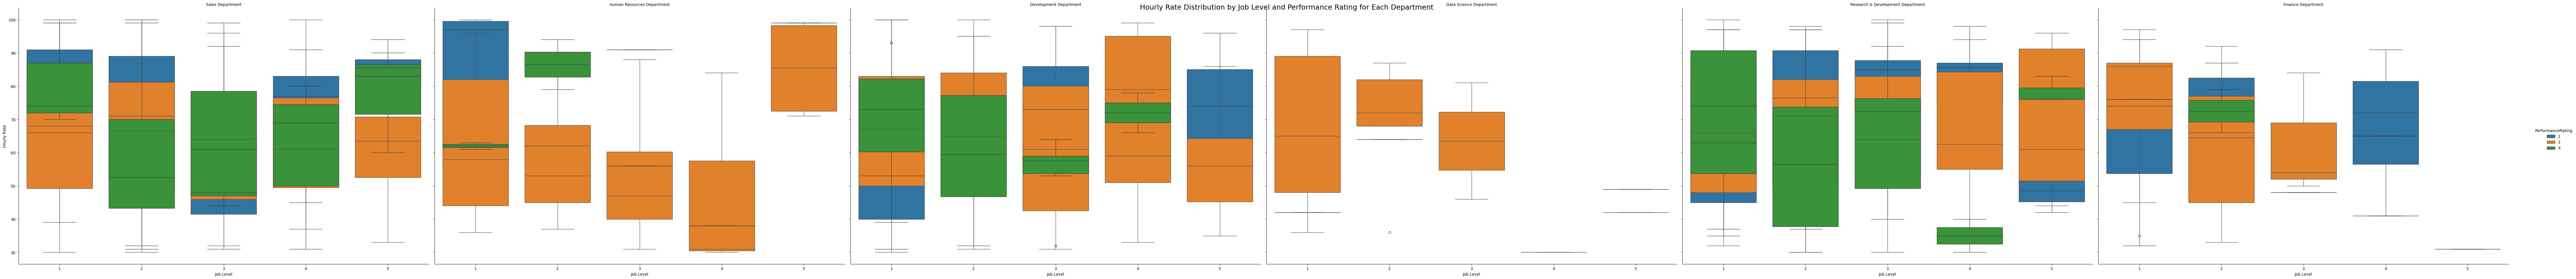

In [ ]:
g = sns.FacetGrid(df, col="EmpDepartment", hue="PerformanceRating", height=10, aspect=1.5)
g.map(sns.boxplot, 'EmpJobLevel', 'EmpHourlyRate')
g.add_legend()
g.set_axis_labels('Job Level', 'Hourly Rate')
g.set_titles("{col_name} Department")
plt.suptitle('Hourly Rate Distribution by Job Level and Performance Rating for Each Department', fontsize=18)
plt.show()


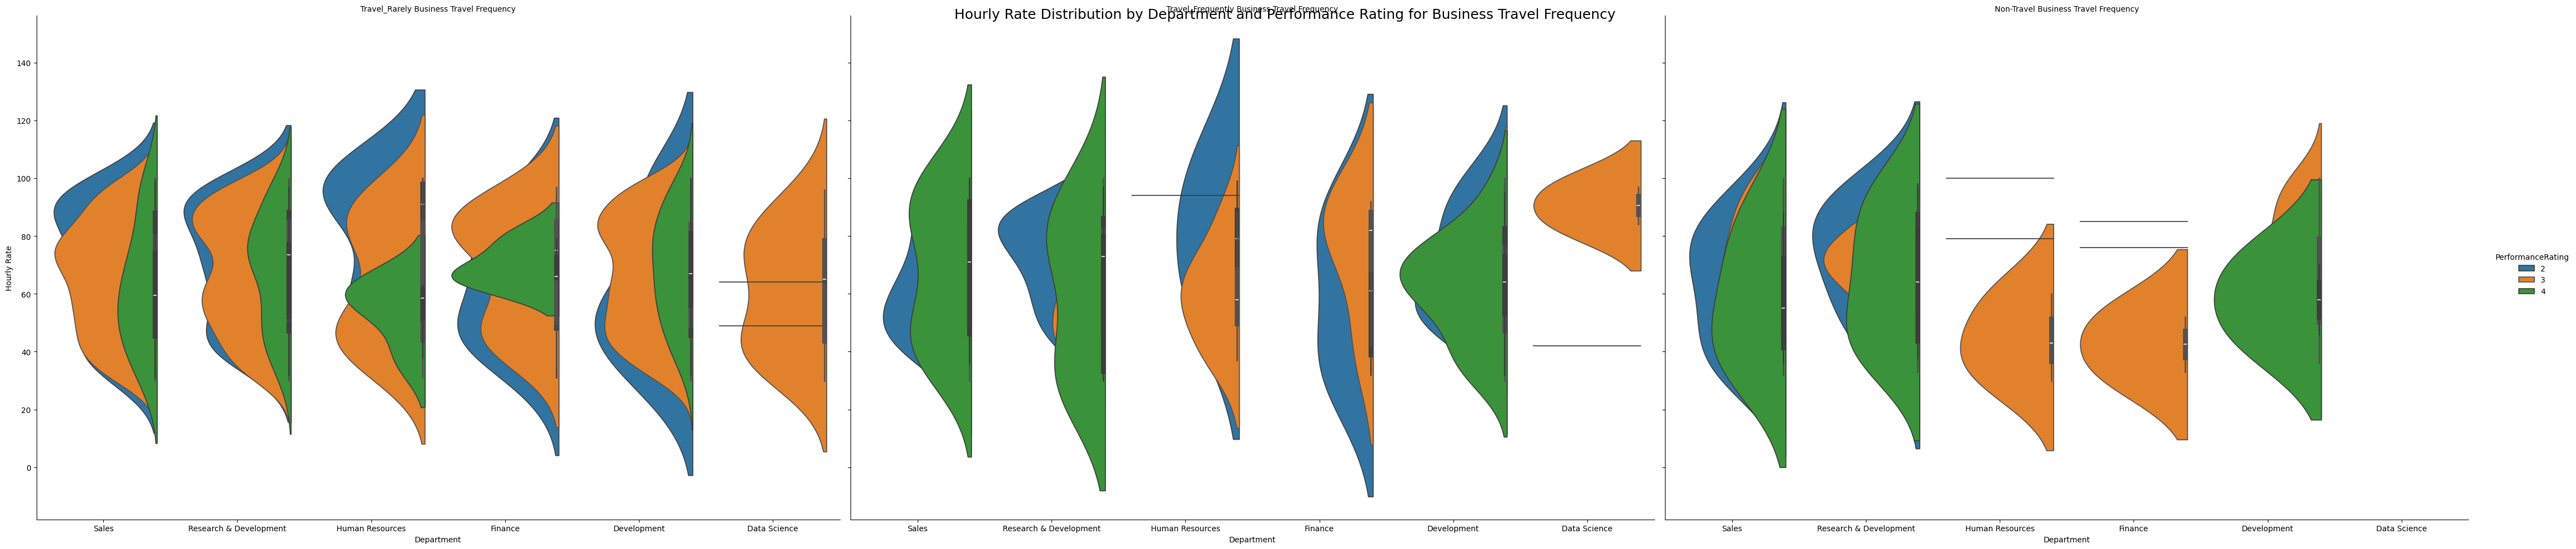

In [ ]:
g = sns.FacetGrid(df, col="BusinessTravelFrequency", hue="PerformanceRating", height=10, aspect=1.5)
g.map(sns.violinplot, 'EmpDepartment', 'EmpHourlyRate', split=True)
g.add_legend()
g.set_axis_labels('Department', 'Hourly Rate')
g.set_titles("{col_name} Business Travel Frequency")
plt.suptitle('Hourly Rate Distribution by Department and Performance Rating for Business Travel Frequency', fontsize=18)
plt.show()


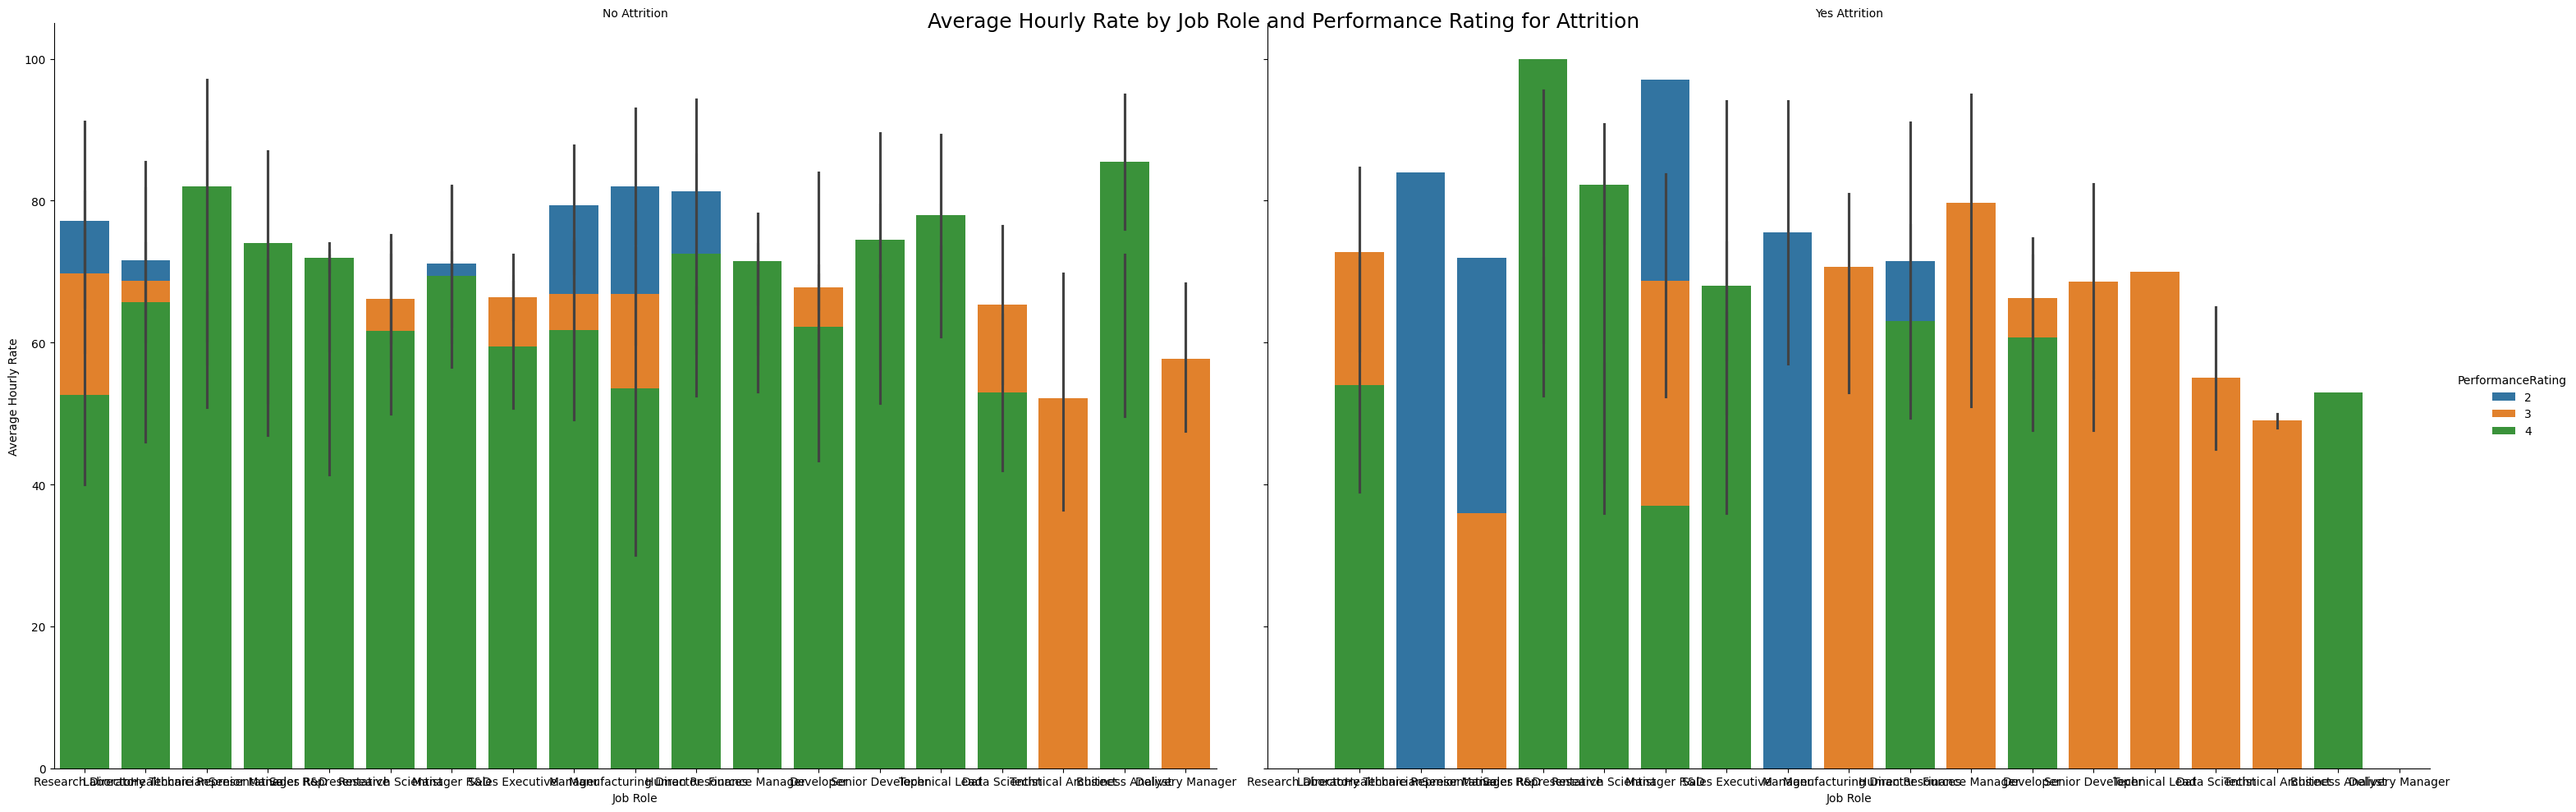

In [ ]:
g = sns.FacetGrid(df, col="Attrition", hue="PerformanceRating", height=10, aspect=1.5)
g.map(sns.barplot, 'EmpJobRole', 'EmpHourlyRate')
g.add_legend()
g.set_axis_labels('Job Role', 'Average Hourly Rate')
g.set_titles("{col_name} Attrition")
plt.suptitle('Average Hourly Rate by Job Role and Performance Rating for Attrition', fontsize=18)
plt.show()


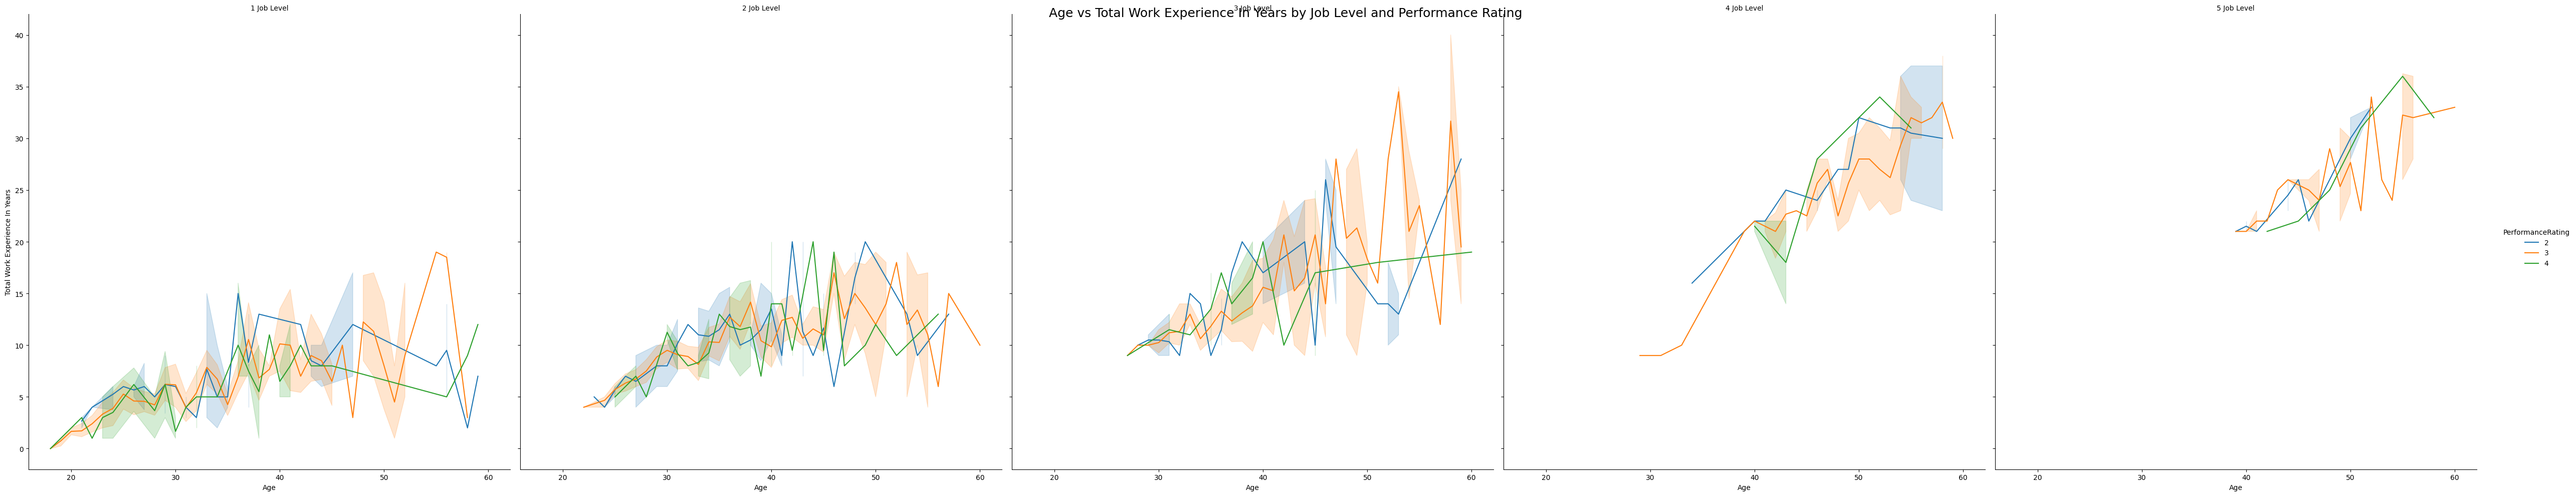

In [ ]:
g = sns.FacetGrid(df, col="EmpJobLevel", hue="PerformanceRating", height=10, aspect=1)
g.map(sns.lineplot, 'Age', 'TotalWorkExperienceInYears')
g.add_legend()
g.set_axis_labels('Age', 'Total Work Experience In Years')
g.set_titles("{col_name} Job Level")
plt.suptitle('Age vs Total Work Experience In Years by Job Level and Performance Rating', fontsize=18)
plt.show()


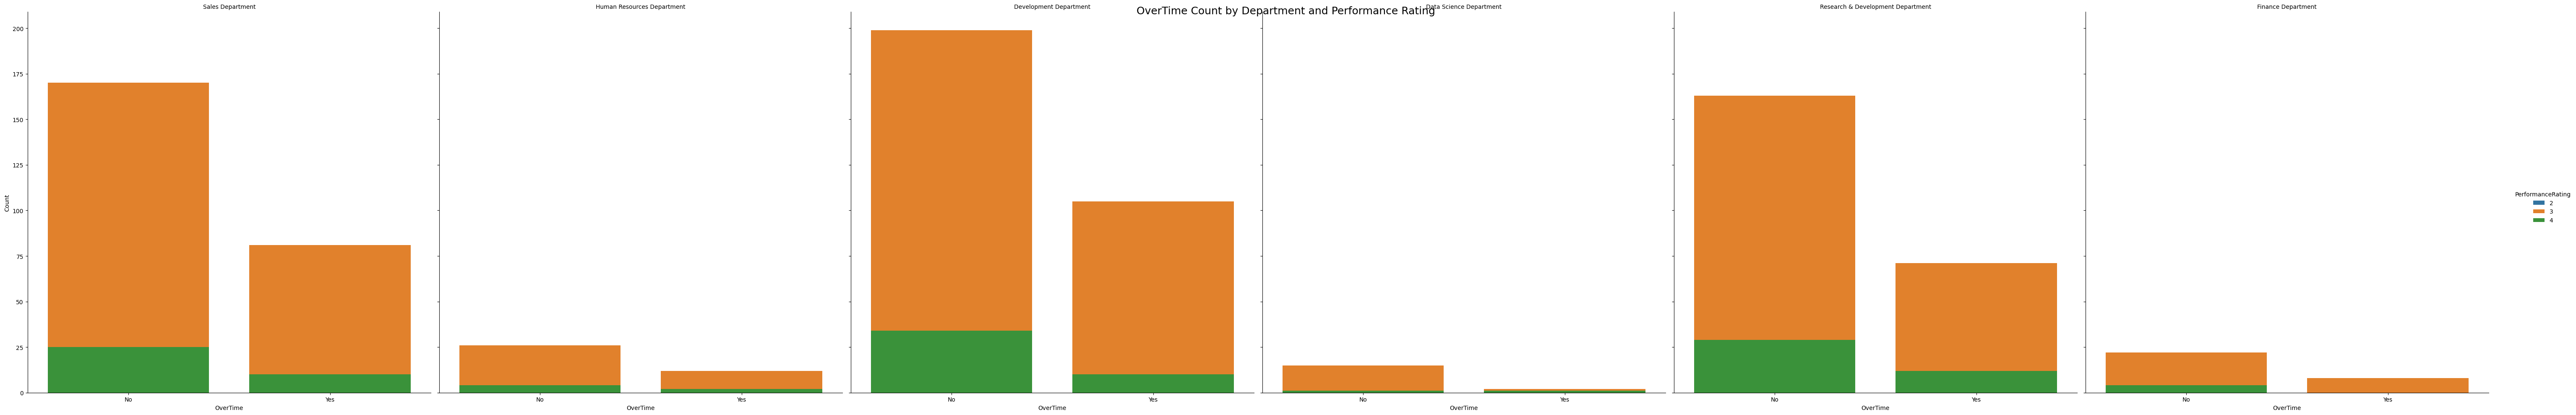

In [ ]:
g = sns.FacetGrid(df, col="EmpDepartment", hue="PerformanceRating", height=10, aspect=1)
g.map(sns.countplot, 'OverTime')
g.add_legend()
g.set_axis_labels('OverTime', 'Count')
g.set_titles("{col_name} Department")
plt.suptitle('OverTime Count by Department and Performance Rating', fontsize=18)
plt.show()


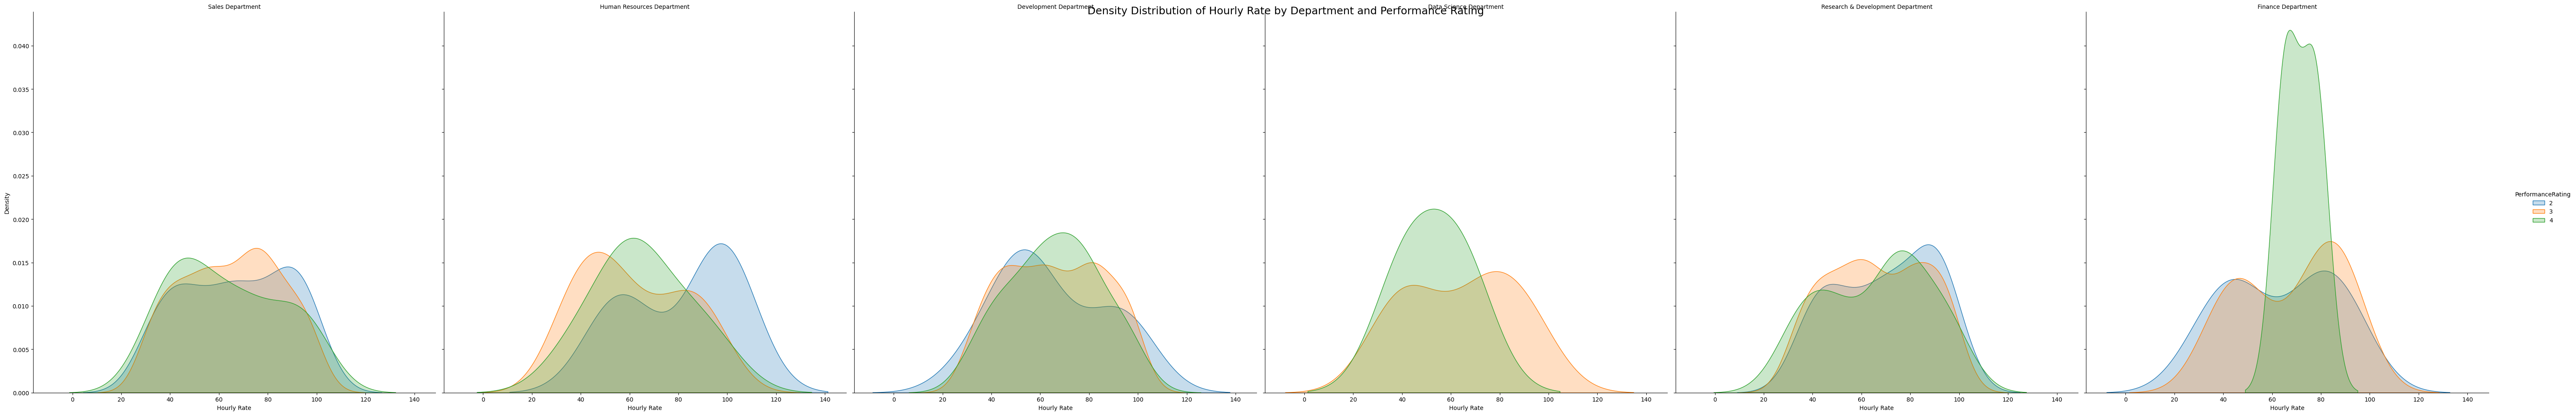

In [ ]:
g = sns.FacetGrid(df, col="EmpDepartment", hue="PerformanceRating", height=10, aspect=1)
g.map(sns.kdeplot, 'EmpHourlyRate', fill=True)
g.add_legend()
g.set_axis_labels('Hourly Rate', 'Density')
g.set_titles("{col_name} Department")
plt.suptitle('Density Distribution of Hourly Rate by Department and Performance Rating', fontsize=18)
plt.show()


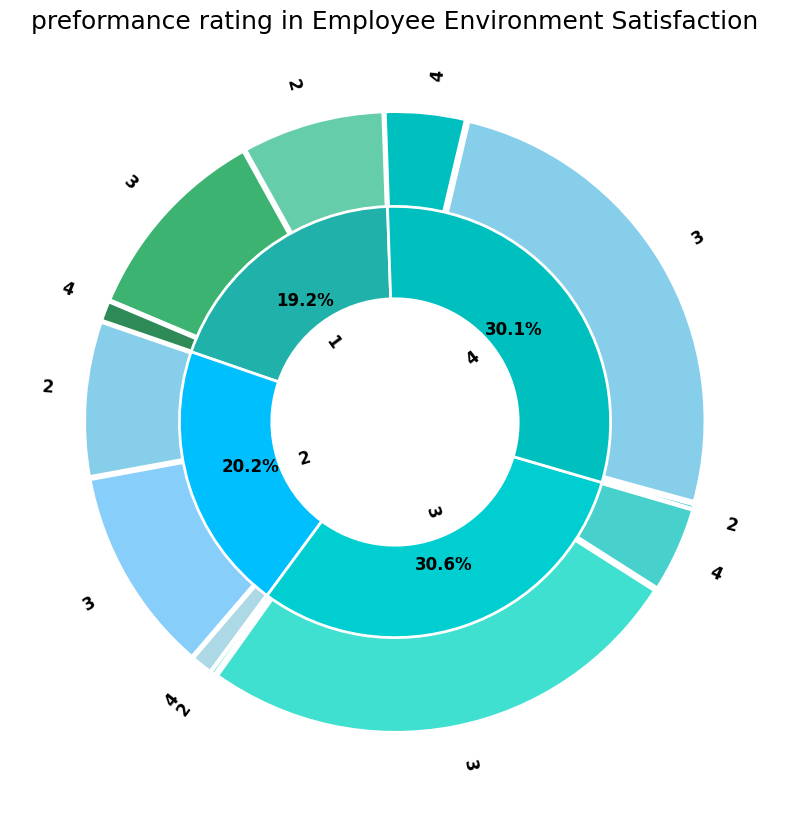

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plt.title("preformance rating in Employee Environment Satisfaction",fontsize=18)
plt.pie([90,127,13,98,130,14,3,310,54,3,307,51], radius=1,
        colors=["mediumaquamarine","mediumseagreen","seagreen",
                "skyblue","lightskyblue",'lightblue',
                'turquoise','turquoise','mediumturquoise',
                'c','skyblue','c',
               ],explode =[0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01],
        labels=[2,3,4,2,3,4,2,3,4,2,3,4],rotatelabels=True,
        pctdistance=0.82, textprops = {"fontsize":12,"fontweight":"bold"},startangle=92,
        wedgeprops=dict(width=0.6, edgecolor='w',linewidth=3))

plt.pie([230,242,367,361], radius=0.7,
        colors=['lightseagreen','deepskyblue',"darkturquoise","c"],
        wedgeprops=dict(width=0.3, edgecolor='w',linewidth=2),textprops = {"fontsize":12,"fontweight":"bold"},
        autopct='%.1f%%',
        labels=[1,2,3,4],
        pctdistance=0.70, labeldistance=0.4, rotatelabels=True,startangle=92)
plt.show()